# 📊 Notebook 02 — Análise Exploratória dos Dados (EDA)

**Tech Challenge Fase 1 — NPS Preditivo para E-commerce**

**Equipe:** Ana Beatriz Porto | Cristiane Marina de Oliveira | Felipe Nadal de Oliveira | Leonardo Neves de Carvalho | Rafael Maia Frenhe

**Pós Tech FIAP — AI Scientist**

---

## Sobre este notebook

Este notebook responde ao **Requisito 3** do Tech Challenge e incorpora insights de **investigações aprofundadas (Requisito 4)**. Toda a análise é escrita como se estivéssemos apresentando para um(a) gerente de operações que não entende estatística.

### Perguntas que vamos responder

| Pergunta do desafio | Onde respondemos |
|---------------------|-----------------|
| Quais fatores parecem mais críticos para a satisfação? | Seções 2, 3, 4 e 11 |
| O que mais gera detratores? | Seções 3, 4 e 5 |
| Existe algum "ponto de ruptura" na experiência? | Seção 3 |
| Que tipo de cliente tende a ter NPS mais alto ou mais baixo? | Seções 5 e 6 |
| Como um modelo preditivo poderia apoiar a empresa? | Seção 13 |
| Como essa solução impacta o negócio? | Seção 12 |

## 0. Preparação do ambiente

In [ ]:
# Bibliotecas necessárias
import pandas as pd           # para tabelas de dados
import numpy as np            # para contas matemáticas
import matplotlib.pyplot as plt  # para gráficos
import seaborn as sns            # para gráficos bonitos
import warnings
warnings.filterwarnings('ignore')

# Cores que usaremos em todos os gráficos
VERDE    = '#2ecc71'
VERMELHO = '#e74c3c'
AMARELO  = '#f39c12'
AZUL     = '#3498db'

# Tamanho e qualidade dos gráficos
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

print("Ambiente pronto!")

Ambiente pronto!


In [ ]:
# Carregando a base de dados
dados = pd.read_csv('desafio_nps_fase_1.csv')

# Quantas linhas e colunas temos?
linhas, colunas = dados.shape
print(f"- A base tem {linhas} clientes e {colunas} colunas\n")

# Tem algum dado faltando?
faltantes = dados.isnull().sum().sum()
print(f"- Dados faltantes: {faltantes} \n")

# Tem algum dado duplicado?
duplicado = dados.duplicated().sum().sum()
print(f"- Dados duplicados: {duplicado} \n")

# Mostrando as 5 primeiras linhas para conferir
print("- Base de dados: ")
dados.head()

- A base tem 2500 clientes e 19 colunas

- Dados faltantes: 0 

- Dados duplicados: 0 

- Base de dados: 


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [ ]:
# Removendo as colunas "customer_id" e "order_id"
dados.drop(['customer_id', 'order_id'], axis=1, inplace=True)

# Confirmando se as colunas foram removidas
dados.columns

Index(['customer_age', 'customer_region', 'customer_tenure_months',
       'order_value', 'items_quantity', 'discount_value',
       'payment_installments', 'delivery_time_days', 'delivery_delay_days',
       'freight_value', 'delivery_attempts', 'customer_service_contacts',
       'resolution_time_days', 'nps_score', 'repeat_purchase_30d',
       'complaints_count', 'csat_internal_score'],
      dtype='object')

Após a análise inicial das variáveis e de seus significados no dataset, optamos pela remoção de `customer_id` e `order_id`, pois esses campos atuam apenas como identificadores e não contribuem para a explicação da satisfação do cliente. Essa decisão permite focar a análise nos fatores operacionais com potencial impacto no NPS, reduzindo ruídos desnecessários.

Antes de aprofundar a análise exploratória, vamos verificar as informações estruturais e estatísticas do DataFrame, a fim de avaliar a qualidade dos dados e os tipos de variáveis.

In [ ]:
# Verificando as informações do DataFrame
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_age               2500 non-null   int64  
 1   customer_region            2500 non-null   object 
 2   customer_tenure_months     2500 non-null   int64  
 3   order_value                2500 non-null   float64
 4   items_quantity             2500 non-null   int64  
 5   discount_value             2500 non-null   float64
 6   payment_installments       2500 non-null   int64  
 7   delivery_time_days         2500 non-null   int64  
 8   delivery_delay_days        2500 non-null   int64  
 9   freight_value              2500 non-null   float64
 10  delivery_attempts          2500 non-null   int64  
 11  customer_service_contacts  2500 non-null   int64  
 12  resolution_time_days       2500 non-null   int64  
 13  nps_score                  2500 non-null   float

In [ ]:
# Analisando as informações descritivas dos dados
dados.describe()

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,43.396000,61.322400,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,14.888487,34.478729,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,18.000000,1.000000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,31.000000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,43.000000,62.000000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,56.000000,91.000000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,69.000000,119.000000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


---
## 1. Panorama da Satisfação — Como estão nossos clientes?
Antes de mergulhar nos detalhes, vamos entender o cenário geral da distribuição das variáveis numéricas com o objetivo de compreender o comportamento dos dados, identificar possíveis assimetrias, concentrações, valores extremos e apoiar decisões sobre tratamentos ou transformações necessárias.

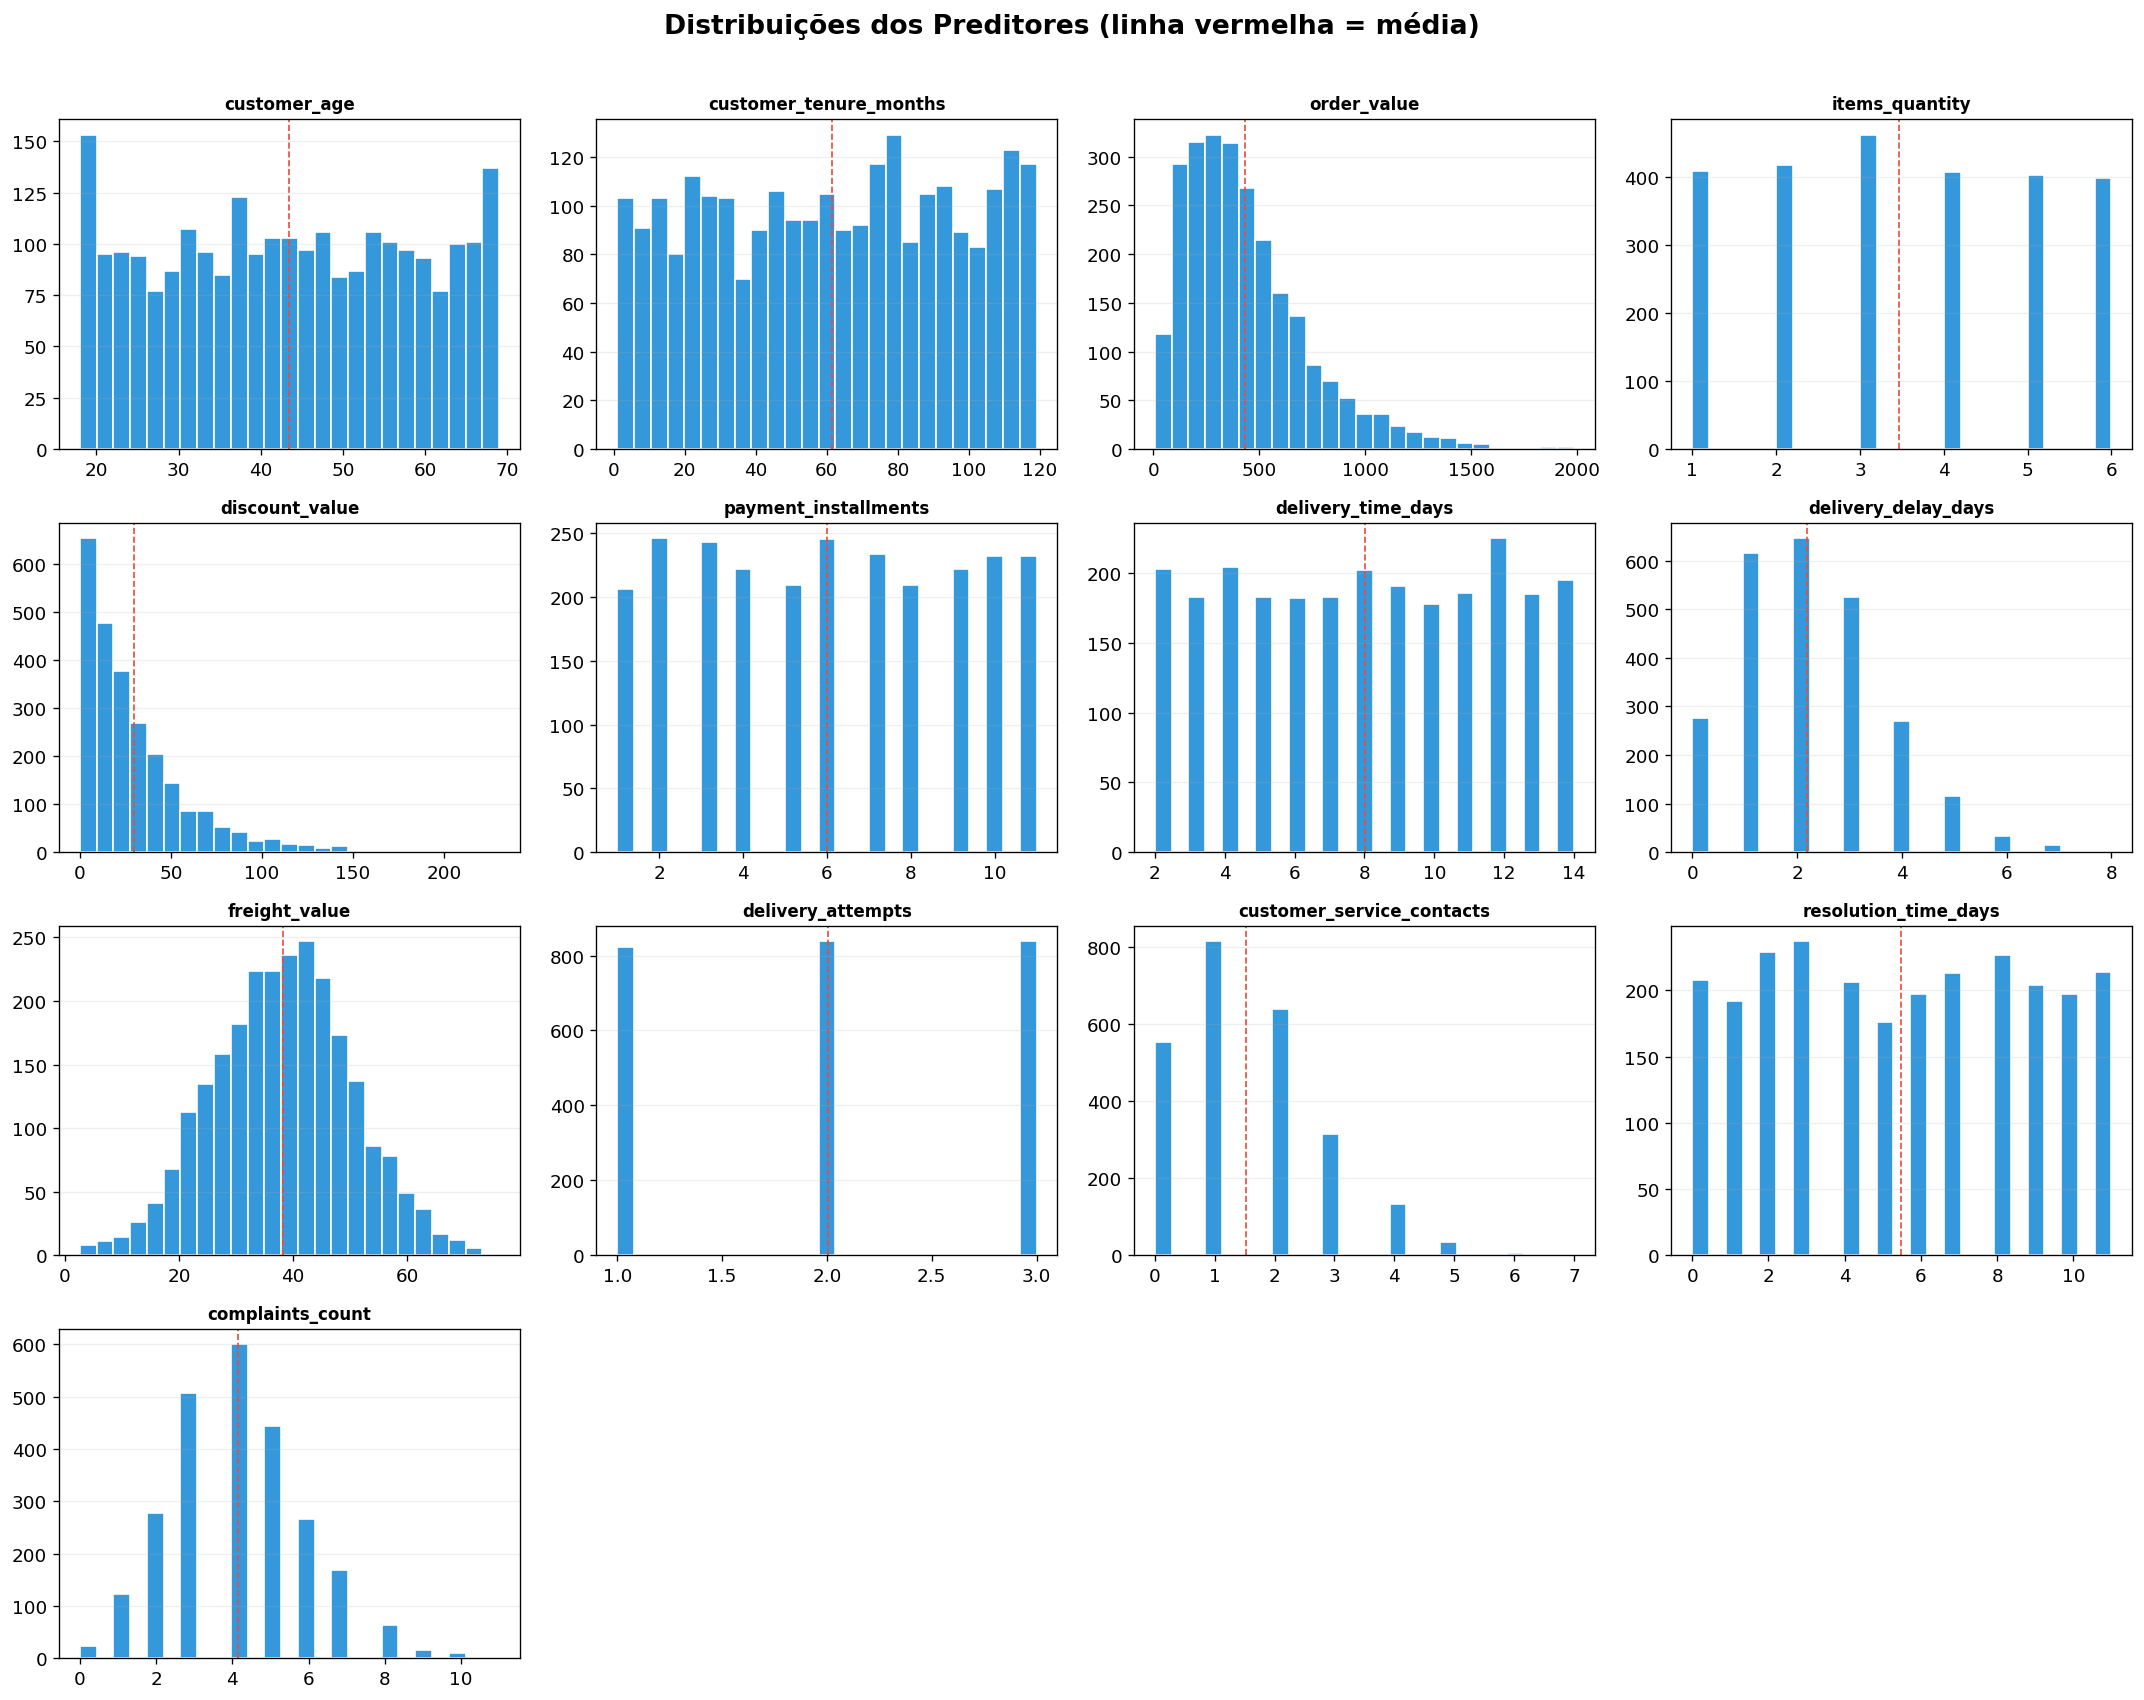

In [ ]:
# Histograma de cada variável numérica
variaveis_hist = [
    'customer_age', 'customer_tenure_months', 'order_value',
    'items_quantity', 'discount_value', 'payment_installments',
    'delivery_time_days', 'delivery_delay_days', 'freight_value',
    'delivery_attempts', 'customer_service_contacts',
    'resolution_time_days', 'complaints_count'
]

fig, grades = plt.subplots(4, 4, figsize=(18, 14))
grades = grades.flatten()

for i, var in enumerate(variaveis_hist):
    grades[i].hist(dados[var], bins=25, color=AZUL, edgecolor='white')
    grades[i].set_title(var, fontsize=10, fontweight='bold')
    grades[i].axvline(dados[var].mean(), color=VERMELHO, linestyle='--', linewidth=1)
    grades[i].grid(axis='y', alpha=0.2)

# Escondendo gráficos extras
for j in range(len(variaveis_hist), len(grades)):
    grades[j].set_visible(False)

plt.suptitle('Distribuições dos Preditores (linha vermelha = média)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('A_distribuicoes.png', dpi=150, bbox_inches='tight')
plt.show()

Na sequência, a target `nps_score` é analisada de forma mais detalhada, buscando compreender seu comportamento. Além disso, é realizada a classificação do NPS por meio de uma função, permitindo categorizar clientes em promotores, neutros e detratores e facilitar análises orientadas ao negócio.

In [ ]:
# Classificando cada cliente
# NPS 0-6 = Detrator | NPS 7-8 = Neutro | NPS 9-10 = Promotor
def classificar(nota):
    if nota <= 6:
        return 'Detrator (0-6)'
    elif nota <= 8:
        return 'Neutro (7-8)'
    else:
        return 'Promotor (9-10)'

dados['categoria'] = dados['nps_score'].apply(classificar)

In [ ]:
# Confirmando classificação através da visualização de uma linha para cada categoria
dados.drop_duplicates(subset='categoria')

,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,categoria
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,Neutro (7-8)
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,Detrator (0-6)
22,50,Sul,81,578.34,3,28.67,5,2,0,38.37,1,0,2,10.0,1,0,8.6,Promotor (9-10)


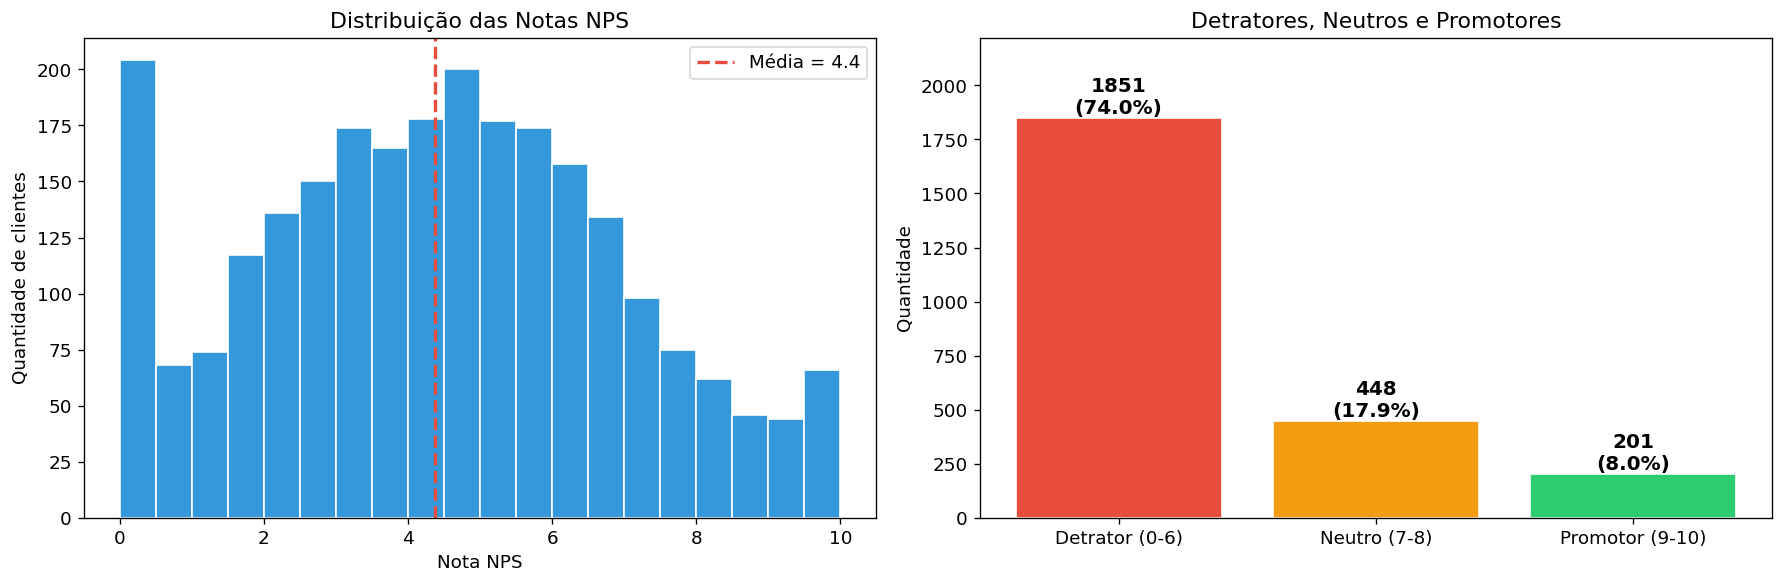

In [ ]:
# Contando cada categoria e ordenando-as da maior para menor
contagem = dados['categoria'].value_counts().sort_index()
total = len(dados)

# Gráfico 1: Histograma das notas
fig, (g1, g2) = plt.subplots(1, 2, figsize=(15, 5))

g1.hist(dados['nps_score'], bins=20, color=AZUL, edgecolor='white')
g1.axvline(dados['nps_score'].mean(), color=VERMELHO, linestyle='--',
           linewidth=2, label=f"Média = {dados['nps_score'].mean():.1f}")
g1.set_xlabel('Nota NPS')
g1.set_ylabel('Quantidade de clientes')
g1.set_title('Distribuição das Notas NPS')
g1.legend()

# Gráfico 2: Barras por categoria
cores = [VERMELHO, AMARELO, VERDE]
barras = g2.bar(contagem.index, contagem.values, color=cores, edgecolor='white')

# Escrevendo o número em cima de cada barra
for barra, qtd in zip(barras, contagem.values):
    pct = qtd / total * 100
    g2.text(barra.get_x() + barra.get_width()/2,
            barra.get_height() + 20,
            f"{qtd}\n({pct:.1f}%)",
            ha='center', fontweight='bold', fontsize=12)

g2.set_ylabel('Quantidade')
g2.set_title('Detratores, Neutros e Promotores')
g2.set_ylim(0, max(contagem.values) * 1.2)

plt.tight_layout()
plt.savefig('01_panorama_nps.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Calculando o NPS de mercado
promotores = (dados['categoria'] == 'Promotor (9-10)').sum()
detratores = (dados['categoria'] == 'Detrator (0-6)').sum()
pct_promotores = promotores / total * 100
pct_detratores = detratores / total * 100
nps_mercado = pct_promotores - pct_detratores

print(f"Promotores: {promotores} clientes ({pct_promotores:.0f}%)")
print(f"Detratores: {detratores} clientes ({pct_detratores:.0f}%)")
print(f"")
print(f"NPS de mercado = {pct_promotores:.0f}% - {pct_detratores:.0f}% = {nps_mercado:.0f}")

Promotores: 201 clientes (8%)
Detratores: 1851 clientes (74%)

NPS de mercado = 8% - 74% = -66


### 💡 Insight 1 — O cenário é alarmante: NPS = −66

**74% dos clientes são detratores**, apenas 8% são promotores.

#### Como funciona o NPS de mercado?

Quando uma empresa divulga "nosso NPS é X", ela não está falando da nota média. Ela usa uma fórmula que transforma todas as notas em **um único número** de **−100 a +100**:

**Passo 1:** Cada cliente dá sua nota de 0 a 10.

**Passo 2:** Classificamos em 3 grupos:
- **Promotores** (nota 9-10) — amam a marca e recomendam
- **Neutros** (nota 7-8) — estão "ok", nem recomendam nem criticam
- **Detratores** (nota 0-6) — insatisfeitos, podem falar mal

**Passo 3:** A fórmula:

> **NPS = % de Promotores − % de Detratores**

Os neutros **não entram** na conta.

#### Aplicando aos nossos dados:

| Grupo | Clientes | % |
|-------|---------|---|
| Promotores (9-10) | 201 | 8% |
| Neutros (7-8) | 448 | 18% |
| Detratores (0-6) | 1.851 | 74% |

**NPS = 8% − 74% = −66**

#### O que −66 significa?

Pense numa balança: de um lado, 8 pessoas recomendando a empresa; do outro, 74 falando mal. O saldo é **−66** — como uma conta bancária no vermelho profundo.

| NPS | Significado | Exemplos |
|-----|-----------|----------|
| +70 a +100 | Excepcional | Apple, Netflix |
| +50 a +70 | Excelente | Nubank |
| +30 a +50 | Bom | Média do e-commerce BR |
| 0 a +30 | Precisa melhorar | — |
| −30 a 0 | Ruim | — |
| −100 a −30 | Crítico | — |
| **−66** | 🚨 **Emergência** | **Esta empresa** |

A empresa está perdendo clientes mais rápido do que conquista. Para cada promotor, existem **9 detratores**.

---
## 2. Os Vilões — O que destrói o NPS?

Vamos medir o quanto cada variável "anda junto" com o NPS. Isso se chama **correlação** e vai de −1 a +1. Valor negativo = "quando um sobe, o outro desce".

In [ ]:
# Lista de variáveis que vamos testar
variaveis = [
    'delivery_delay_days',
    'complaints_count',
    'customer_service_contacts',
    'resolution_time_days',
    'freight_value',
    'customer_age',
    'customer_tenure_months',
    'delivery_time_days',
    'items_quantity',
    'payment_installments',
    'discount_value',
    'delivery_attempts',
    'order_value'
]

# Calculando a correlação de cada uma com o NPS
resultados = []
for variavel in variaveis:
    correlacao = dados[variavel].corr(dados['nps_score'])
    resultados.append((variavel, correlacao))

# Ordenando do mais negativo pro mais positivo
resultados.sort(key=lambda x: x[1])
nomes = [r[0] for r in resultados]
valores = [r[1] for r in resultados]

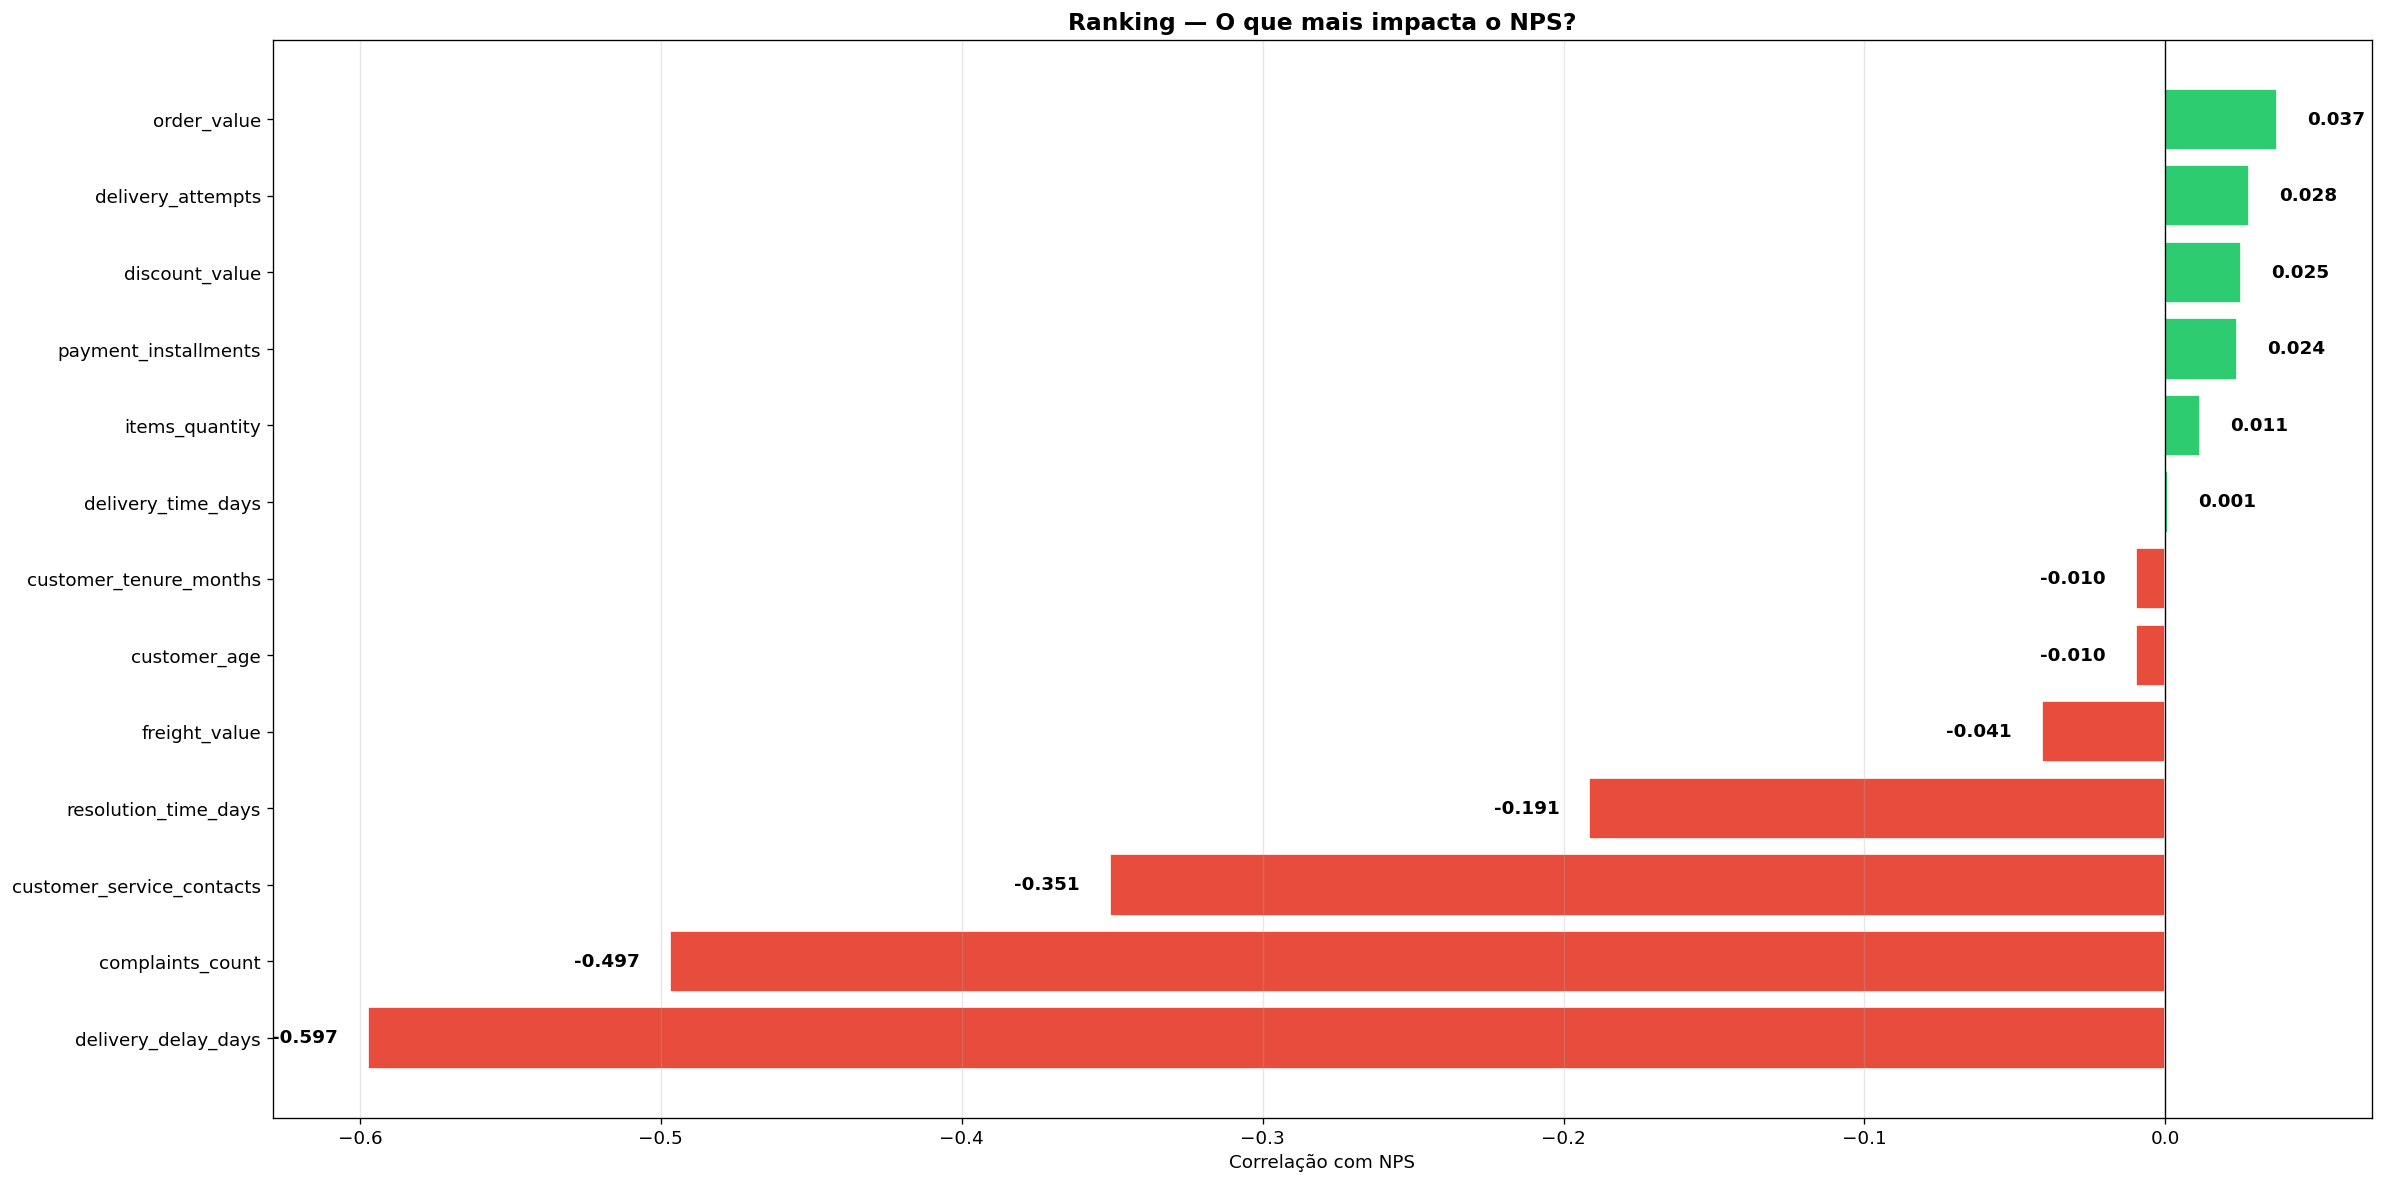

In [ ]:
# Gráfico de barras horizontais
fig, g = plt.subplots(figsize=(20, 10))

cores_barras = []
for v in valores:
    if v < 0:
        cores_barras.append(VERMELHO)
    else:
        cores_barras.append(VERDE)

barras = g.barh(nomes, valores, color=cores_barras, edgecolor='white')

# Escrevendo o valor ao lado de cada barra
for barra, valor in zip(barras, valores):
    if valor >= 0:
        posicao = valor + 0.01
        alinhamento = 'left'
    else:
        posicao = valor - 0.01
        alinhamento = 'right'

    g.text(posicao,
           barra.get_y() + barra.get_height()/2,
           f"{valor:.3f}",
           ha=alinhamento, va='center', fontweight='bold')

g.axvline(0, color='black', linewidth=0.8)
g.set_xlabel('Correlação com NPS')
g.set_title('Ranking — O que mais impacta o NPS?', fontsize=14, fontweight='bold')
g.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('02_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Insight 2 — O top 3 dos vilões

| Rank | Fator | Correlação | O que significa |
|------|-------|-----------|-----------------|
| 🥇 | **Atraso na entrega** | **−0.597** | Quanto mais atraso, mais cai o NPS |
| 🥈 | **Reclamações** | **−0.497** | Mais reclamações = mais insatisfação |
| 🥉 | **Contatos com SAC** | **−0.351** | Cada contato adicional piora |

**O que NÃO impacta:** valor do pedido, desconto e frete têm correlação quase zero. **O cliente não fica insatisfeito pelo preço, mas sim pela experiência depois da compra.**

Boa notícia: o problema não é pricing (difícil de mudar), é **operação** (possível de melhorar).

---
## 3. O Ponto de Ruptura — Até quantos dias de atraso o cliente tolera?

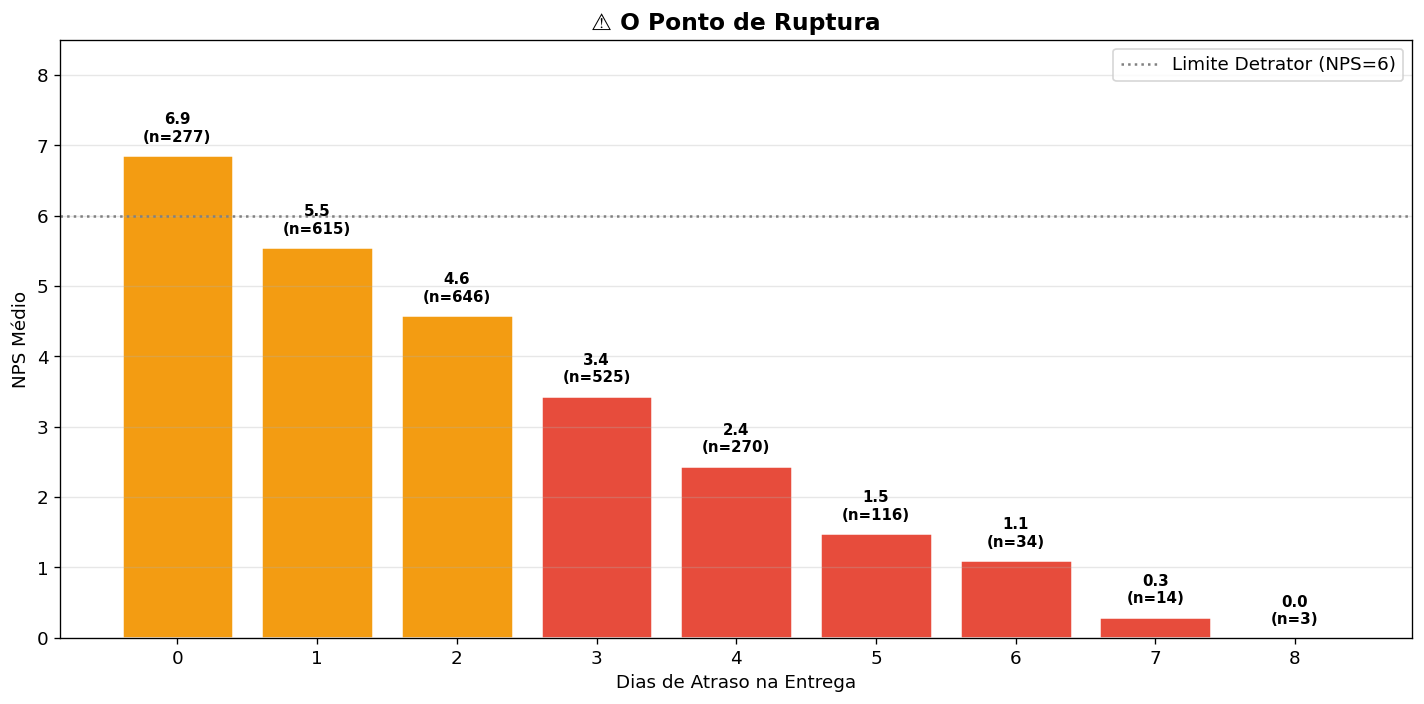


📋 Sem atraso: 277 pedidos (11.1%)
📋 Com atraso: 2223 pedidos (88.9%)


In [ ]:
# Para cada nível de atraso, qual é o NPS médio?
nps_por_atraso = dados.groupby('delivery_delay_days')['nps_score'].mean()
qtd_por_atraso = dados.groupby('delivery_delay_days')['nps_score'].count()

# Gráfico
fig, g = plt.subplots(figsize=(12, 6))

# Cor de cada barra depende do NPS
cores_barras = []
for nps in nps_por_atraso.values:
    if nps >= 7:
        cores_barras.append(VERDE)
    elif nps >= 4:
        cores_barras.append(AMARELO)
    else:
        cores_barras.append(VERMELHO)

g.bar(nps_por_atraso.index, nps_por_atraso.values,
      color=cores_barras, edgecolor='white', linewidth=1.5)

# Linha de referência
g.axhline(6, color='gray', linestyle=':', linewidth=1.5, label='Limite Detrator (NPS=6)')

# Valores em cima
for dias, nps, qtd in zip(nps_por_atraso.index, nps_por_atraso.values, qtd_por_atraso.values):
    g.text(dias, nps + 0.2,
           f"{nps:.1f}\n(n={qtd})",
           ha='center', fontsize=9, fontweight='bold')

g.set_xlabel('Dias de Atraso na Entrega')
g.set_ylabel('NPS Médio')
g.set_title('⚠️ O Ponto de Ruptura', fontsize=14, fontweight='bold')
g.set_xticks(range(0, 9))
g.set_ylim(0, 8.5)
g.legend()
g.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('03_ponto_ruptura.png', dpi=150, bbox_inches='tight')
plt.show()

# Porcentagem com atraso
com_atraso = (dados['delivery_delay_days'] > 0).sum()
sem_atraso = (dados['delivery_delay_days'] == 0).sum()
print(f"\n📋 Sem atraso: {sem_atraso} pedidos ({sem_atraso/total*100:.1f}%)")
print(f"📋 Com atraso: {com_atraso} pedidos ({com_atraso/total*100:.1f}%)")

### 💡 Insight 3 — A escada da insatisfação

| Atraso | NPS médio | O que acontece |
|--------|-----------|----------------|
| **0 dias** | **6.9** | Sem atraso = quase neutro |
| **1 dia** | **5.6** | 1 dia já derruba 1.3 pontos |
| **2 dias** | **4.6** | Queda acumulada de 2.3 pontos |
| **3 dias** | **3.4** | Metade da nota perdida |
| **5 dias** | **1.5** | Cliente praticamente perdido |
| **8 dias** | **0.0** | Destruição total |

**O ponto de ruptura é entre 0 e 1 dia**, já que é a queda mais abrupta.

**89% dos pedidos tem atraso**, ou seja, o problema é sistêmico. Cada dia eliminado retorna ~1 ponto no NPS.

---
## 4. Mapa de Correlações

Após aprofundar a análise do `nps_score`, o mapa de correlação entre as próprias variáveis torna‑se essencial para entender como os fatores que impactam o NPS se relacionam entre si, evitando interpretações isoladas e revelando possíveis efeitos combinados ao longo da jornada do cliente.

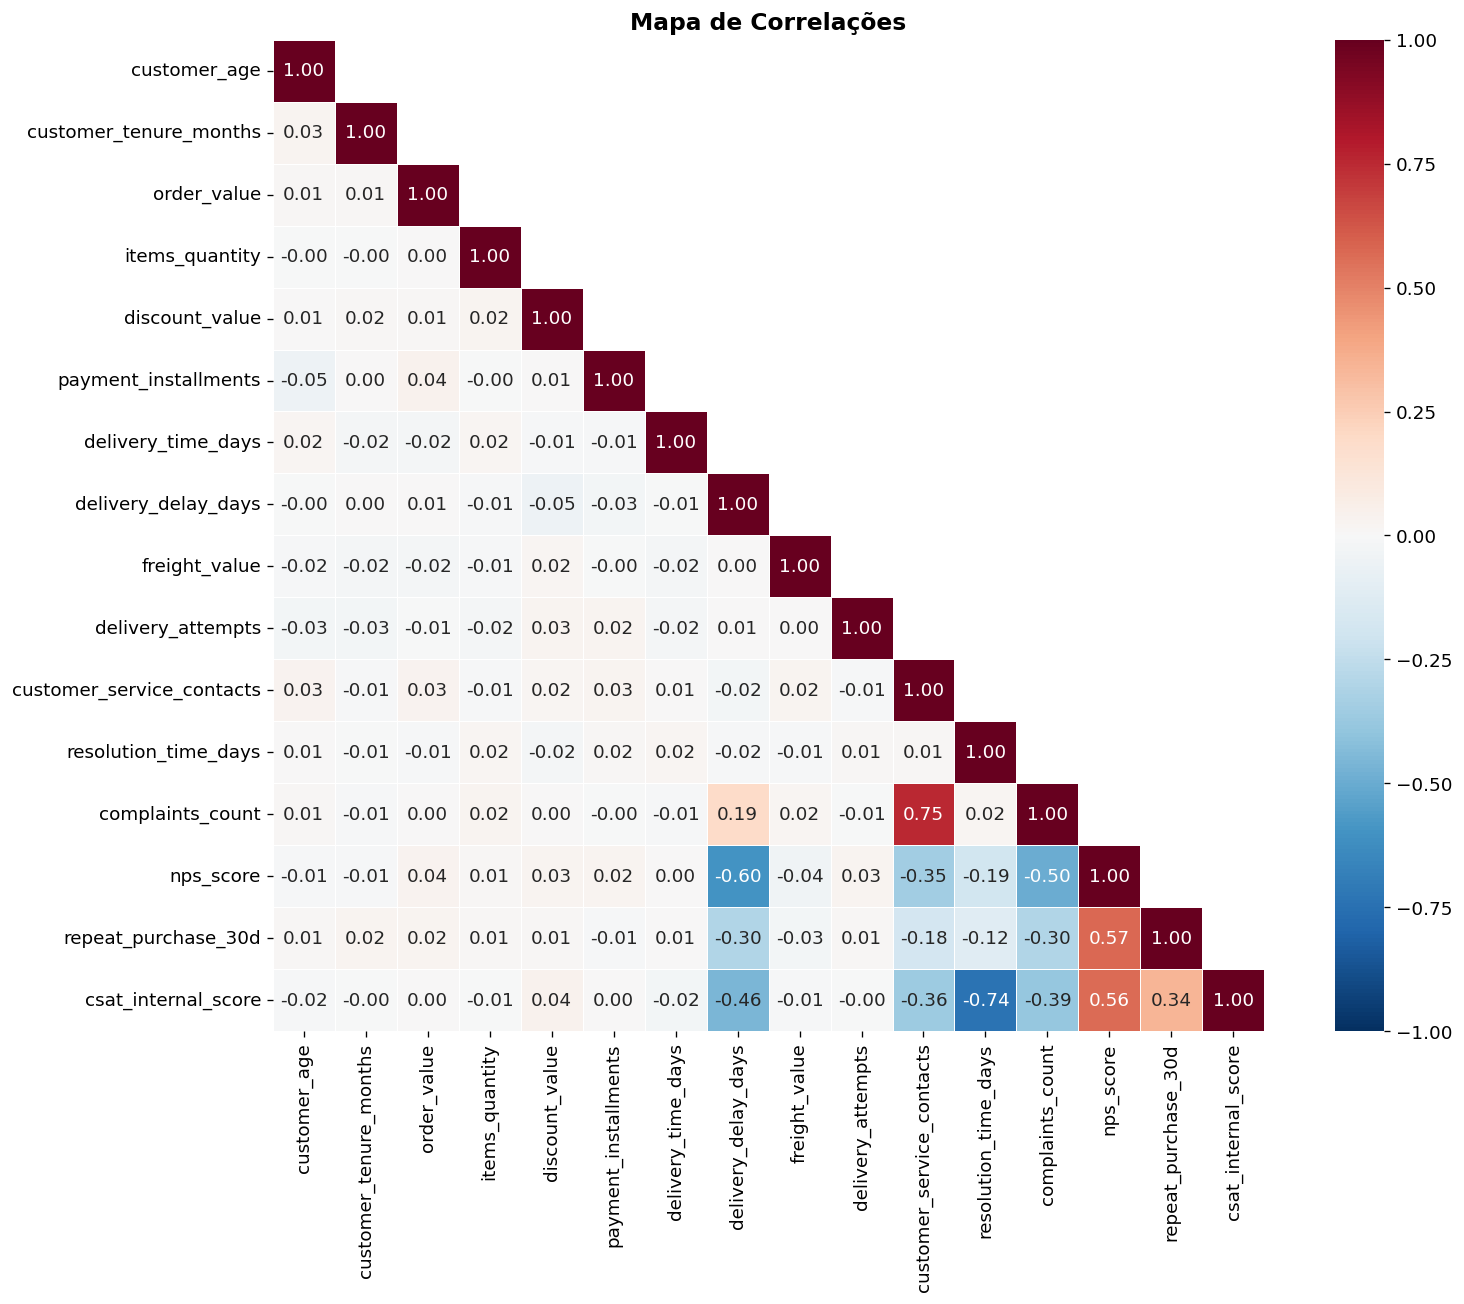

In [ ]:
# Selecionando variáveis numéricas relevantes
colunas = [
    'customer_age', 'customer_tenure_months', 'order_value',
    'items_quantity', 'discount_value', 'payment_installments',
    'delivery_time_days', 'delivery_delay_days', 'freight_value',
    'delivery_attempts', 'customer_service_contacts',
    'resolution_time_days', 'complaints_count',
    'nps_score', 'repeat_purchase_30d', 'csat_internal_score'
]

# Calculando correlações
matriz = dados[colunas].corr()

# Gráfico tipo mapa de calor
fig, g = plt.subplots(figsize=(14, 11))

# Mostra só metade (evita repetição)
mascara = np.triu(np.ones_like(matriz, dtype=bool), k=1)

sns.heatmap(matriz, mask=mascara, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=g)

g.set_title('Mapa de Correlações', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Insight 4 — Relações importantes

- **SAC × Reclamações = 0.75** — quase a mesma coisa (quem reclama, liga)
- **repeat_purchase × NPS = 0.57** — possível leakage
- **Variáveis financeiras** independentes do NPS — preço não determina satisfação

---
## 5. O Efeito Cascata — Reclamações e Atendimento

A correlação apontou ``complaints_count`` e ``customer_service_contacts`` como variáveis-chave e fortemente relacionadas, a segmentação em faixas permite agora observar como o NPS se comporta de forma progressiva conforme o nível de atrito aumenta

In [ ]:
# Criando faixas
dados['faixa_rec'] = pd.cut(dados['complaints_count'],
                            bins=[-1, 0, 2, 4, 6, 11],
                            labels=['0', '1-2', '3-4', '5-6', '7+'])

dados['faixa_sac'] = pd.cut(dados['customer_service_contacts'],
                            bins=[-1, 0, 1, 2, 3, 7],
                            labels=['0', '1', '2', '3', '4+'])

# NPS médio por faixa
nps_rec = dados.groupby('faixa_rec')['nps_score'].mean()
qtd_rec = dados.groupby('faixa_rec')['nps_score'].count()

nps_sac = dados.groupby('faixa_sac')['nps_score'].mean()
qtd_sac = dados.groupby('faixa_sac')['nps_score'].count()

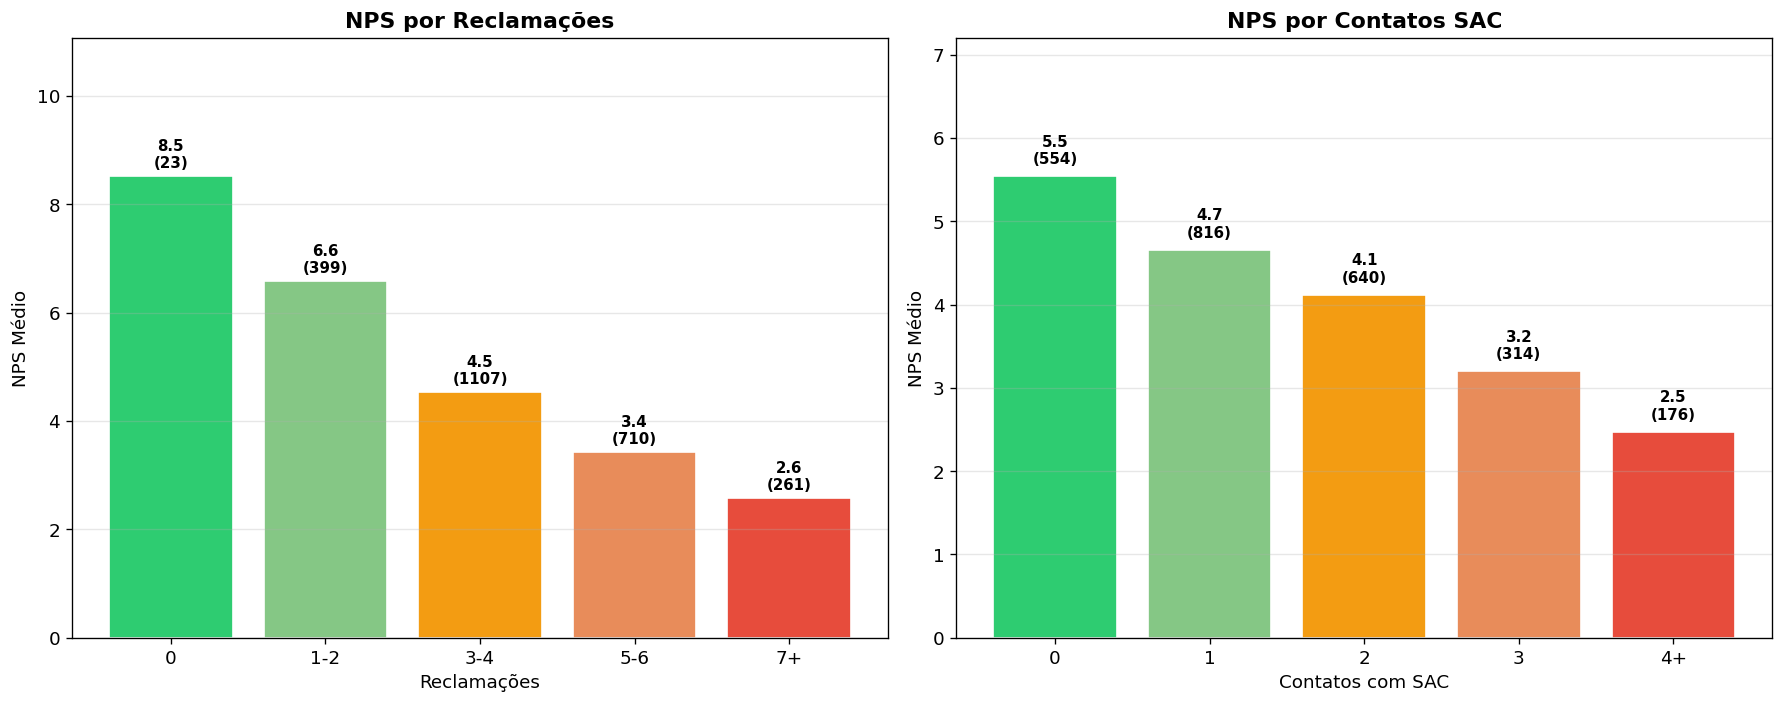


📋 Correlação SAC × Reclamações: 0.75 (muito forte)


In [ ]:
# Gráficos lado a lado
fig, (g1, g2) = plt.subplots(1, 2, figsize=(15, 6))
cores5 = [VERDE, '#85c785', AMARELO, '#e88c5a', VERMELHO]

# Reclamações
g1.bar(nps_rec.index, nps_rec.values, color=cores5, edgecolor='white')
for faixa, nps, qtd in zip(nps_rec.index, nps_rec.values, qtd_rec.values):
    g1.text(faixa, nps + 0.15, f"{nps:.1f}\n({qtd})", ha='center', fontsize=9, fontweight='bold')
g1.set_xlabel('Reclamações')
g1.set_ylabel('NPS Médio')
g1.set_title('NPS por Reclamações', fontweight='bold')
g1.set_ylim(0, max(nps_rec.values) * 1.3)
g1.grid(axis='y', alpha=0.3)

# Contatos SAC
g2.bar(nps_sac.index, nps_sac.values, color=cores5, edgecolor='white')
for faixa, nps, qtd in zip(nps_sac.index, nps_sac.values, qtd_sac.values):
    g2.text(faixa, nps + 0.15, f"{nps:.1f}\n({qtd})", ha='center', fontsize=9, fontweight='bold')
g2.set_xlabel('Contatos com SAC')
g2.set_ylabel('NPS Médio')
g2.set_title('NPS por Contatos SAC', fontweight='bold')
g2.set_ylim(0, max(nps_sac.values) * 1.3)
g2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('04_cascata.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlação entre SAC e reclamações
corr = dados['customer_service_contacts'].corr(dados['complaints_count'])
print(f"\n📋 Correlação SAC × Reclamações: {corr:.2f} (muito forte)")

### 💡 Insight 5 — A cadeia causal

**Atraso → Reclamação → Contato SAC → Insatisfação**

- SAC e reclamações têm correlação de **0.75**, ou seja, quem reclama, liga pro SAC
- **0 reclamações** → NPS de **8.5** (promotores!)
- **7+ reclamações** → NPS de **2.6**
- **0 contatos SAC** → NPS de **5.5**
- **4+ contatos** → NPS de **2.5**

**O SAC não é a causa, é o sintoma.** Resolver o atraso resolve toda a cadeia. Expandir o SAC sem melhorar a logística é tratar o sintoma, não a doença.

---
## 5. Quem é o Detrator? Quem é o Promotor?

O objetivo dessa análise é verificar até que ponto o NPS é explicado apenas por fatores operacionais, como atraso, reclamações e contatos com o SAC, ou se características do perfil do cliente, como idade, valor do pedido e tempo de relacionamento, também influenciam a percepção da experiência. Essa comparação ajuda a entender se o NPS é resultado exclusivo de falhas operacionais ou se envolve fatores estruturais e de relacionamento com outras áreas da empresa.

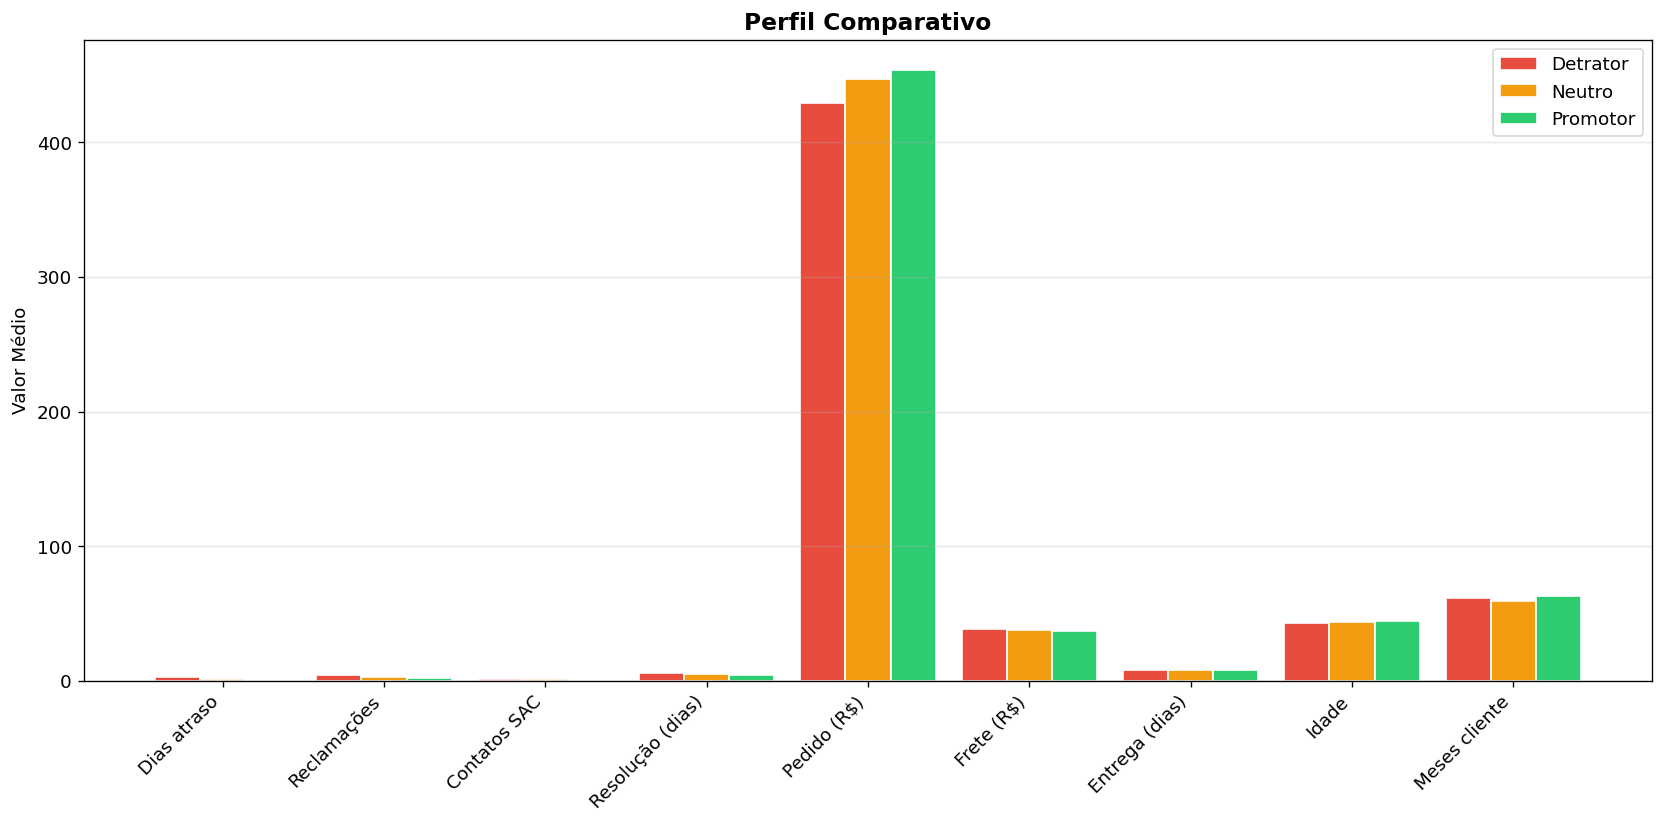


📋 Detrator vs Promotor:
  Dias atraso................... Det:     2.5 | Pro:     0.8
  Reclamações................... Det:     4.6 | Pro:     2.4
  Contatos SAC.................. Det:     1.7 | Pro:     0.8
  Resolução (dias).............. Det:     5.8 | Pro:     4.1
  Pedido (R$)................... Det:   429.0 | Pro:   453.7
  Frete (R$).................... Det:    38.4 | Pro:    37.2
  Entrega (dias)................ Det:     8.0 | Pro:     8.0
  Idade......................... Det:    43.3 | Pro:    44.1
  Meses cliente................. Det:    61.6 | Pro:    63.0


In [ ]:
# Variáveis para comparar
variaveis_perfil = [
    'delivery_delay_days', 'complaints_count', 'customer_service_contacts',
    'resolution_time_days', 'order_value', 'freight_value',
    'delivery_time_days', 'customer_age', 'customer_tenure_months'
]

nomes_amigaveis = [
    'Dias atraso', 'Reclamações', 'Contatos SAC',
    'Resolução (dias)', 'Pedido (R$)', 'Frete (R$)',
    'Entrega (dias)', 'Idade', 'Meses cliente'
]

# Média por categoria
perfil = dados.groupby('categoria')[variaveis_perfil].mean()

# Gráfico de barras agrupadas
fig, g = plt.subplots(figsize=(14, 7))

posicoes = np.arange(len(nomes_amigaveis))
largura = 0.28

g.bar(posicoes - largura,
      perfil.loc['Detrator (0-6)'].values,
      largura, label='Detrator', color=VERMELHO, edgecolor='white')

g.bar(posicoes,
      perfil.loc['Neutro (7-8)'].values,
      largura, label='Neutro', color=AMARELO, edgecolor='white')

g.bar(posicoes + largura,
      perfil.loc['Promotor (9-10)'].values,
      largura, label='Promotor', color=VERDE, edgecolor='white')

g.set_xticks(posicoes)
g.set_xticklabels(nomes_amigaveis, rotation=45, ha='right')
g.set_ylabel('Valor Médio')
g.set_title('Perfil Comparativo', fontsize=14, fontweight='bold')
g.legend(fontsize=11)
g.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('05_perfil.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela resumida
print("\n📋 Detrator vs Promotor:")
for var, nome in zip(variaveis_perfil, nomes_amigaveis):
    det = perfil.loc['Detrator (0-6)', var]
    pro = perfil.loc['Promotor (9-10)', var]
    print(f"  {nome:.<30} Det: {det:>7.1f} | Pro: {pro:>7.1f}")

### 💡 Insight 6 — A diferença é só operacional

| | Detrator | Promotor | |
|---|---------|----------|-|
| **Atraso** | 2.5 dias | 0.8 dias | 3× mais |
| **Reclamações** | 4.6 | 2.4 | 2× mais |
| **Contatos SAC** | 1.7 | 0.8 | 2× mais |
| **Valor pedido** |  429 |  454 | ≈ igual |
| **Idade** | 43 anos | 44 anos | ≈ igual |

**Não existe "perfil de detrator".** Qualquer cliente vira promotor se a operação funcionar.

---
## 6. Análise Regional

As análises indicam que não existe um “perfil de detrator”: a insatisfação não é explicada por características do cliente, mas pelo funcionamento da operação. Diante disso, a análise de NPS por região busca identificar se há localidades onde falhas operacionais se concentram, gerando uma experiência consistentemente pior e impactando o NPS de forma mais intensa.

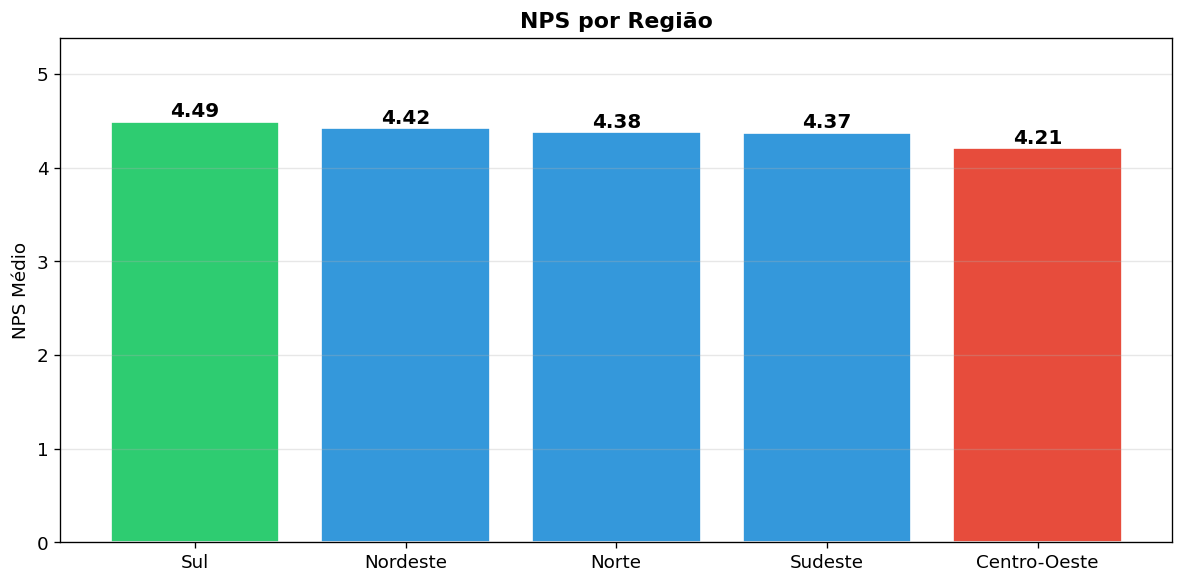

In [ ]:
# NPS por região
nps_regiao = dados.groupby('customer_region')['nps_score'].mean().sort_values(ascending=False)

fig, g = plt.subplots(figsize=(10, 5))
cores_regiao = [VERDE if v == nps_regiao.max() else VERMELHO if v == nps_regiao.min() else AZUL for v in nps_regiao.values]
barras = g.bar(nps_regiao.index, nps_regiao.values, color=cores_regiao, edgecolor='white')

for barra, valor in zip(barras, nps_regiao.values):
    g.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.05,
           f"{valor:.2f}", ha='center', fontweight='bold', fontsize=12)

g.set_ylabel('NPS Médio')
g.set_title('NPS por Região', fontweight='bold')
g.set_ylim(0, max(nps_regiao.values) * 1.2)
g.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('06_regiao.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Insight 7 — Região não é o problema

Diferença entre a melhor (Sul, 4.49) e a pior (Centro-Oeste, 4.21) = **0.28 pontos**, ou seja, irrelevante. O problema é **sistêmico**, não regional.

---
## 8. Leakage — CSAT e Recompra são confiáveis?

Voltando a um insight do mapa de correlação (Capítulo 4), acorrelação entre NPS e recompra levantou a hipótese de um possível leakage de valor. A análise por categoria busca validar se essa relação se sustenta no comportamento real dos clientes, conectando percepção da experiência a impacto direto em retenção.

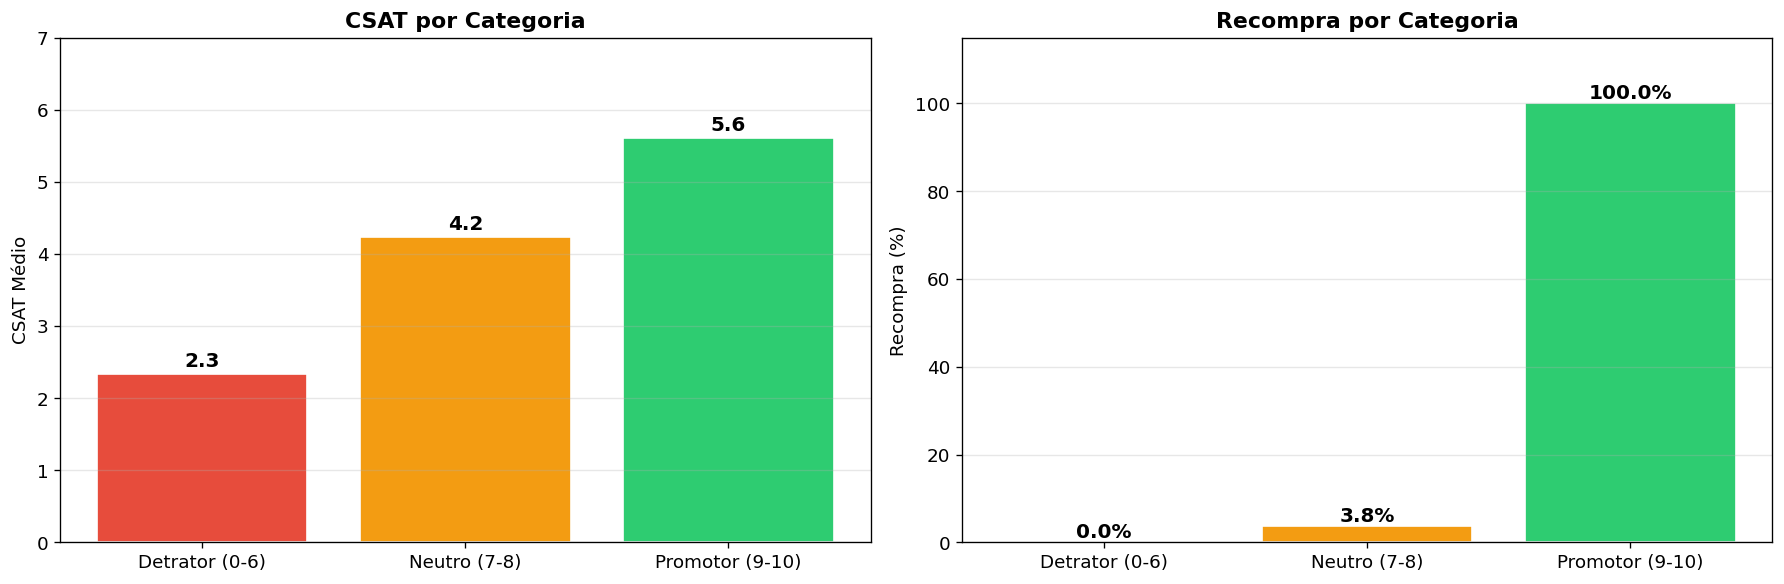

In [ ]:
# CSAT e recompra por categoria NPS
csat = dados.groupby('categoria')['csat_internal_score'].mean()
recompra = dados.groupby('categoria')['repeat_purchase_30d'].mean() * 100

fig, (g1, g2) = plt.subplots(1, 2, figsize=(15, 5))
cores = [VERMELHO, AMARELO, VERDE]

# CSAT
barras1 = g1.bar(csat.index, csat.values, color=cores, edgecolor='white')
for b, v in zip(barras1, csat.values):
    g1.text(b.get_x()+b.get_width()/2, v+0.1, f"{v:.1f}", ha='center', fontsize=12, fontweight='bold')
g1.set_ylabel('CSAT Médio')
g1.set_title('CSAT por Categoria', fontweight='bold')
g1.set_ylim(0, 7)
g1.grid(axis='y', alpha=0.3)

# Recompra
barras2 = g2.bar(recompra.index, recompra.values, color=cores, edgecolor='white')
for b, v in zip(barras2, recompra.values):
    g2.text(b.get_x()+b.get_width()/2, v+1, f"{v:.1f}%", ha='center', fontsize=12, fontweight='bold')
g2.set_ylabel('Recompra (%)')
g2.set_title('Recompra por Categoria', fontweight='bold')
g2.set_ylim(0, 115)
g2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('08_leakage.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Insight 8 — Leakage detectado na recompra

| Categoria | CSAT | Recompra |
|-----------|------|---------|
| Detrator | 2.3 | **0.0%** |
| Neutro | 4.2 | 3.8% |
| Promotor | 5.6 | **100.0%** |

Recompra 0% para detratores e 100% para promotores é **perfeito demais** tornando-se um forte sinal de leakage (variável derivada do NPS). Mantemos na análise com alerta.

---
## 9. O que faz um cliente voltar?

Investigando os fatores da recompra e sua relação com NPS.

In [ ]:
# Separando quem recomprou
sim = dados[dados['repeat_purchase_30d'] == 1]
nao = dados[dados['repeat_purchase_30d'] == 0]

print(f"📋 Recompraram: {len(sim)} ({len(sim)/total*100:.1f}%)")
print(f"📋 Menor NPS de quem recomprou: {sim['nps_score'].min()}")

# Filtros eliminatórios
print(f"\n📋 Filtros que eliminam a recompra:")
for dias in [3, 4, 5]:
    sub = dados[dados['delivery_delay_days'] >= dias]
    pct = sub['repeat_purchase_30d'].mean() * 100
    print(f"  Atraso ≥ {dias} dias → recompra = {pct:.1f}%")

📋 Recompraram: 218 (8.7%)
📋 Menor NPS de quem recomprou: 8.0

📋 Filtros que eliminam a recompra:
  Atraso ≥ 3 dias → recompra = 0.7%
  Atraso ≥ 4 dias → recompra = 0.2%
  Atraso ≥ 5 dias → recompra = 0.0%


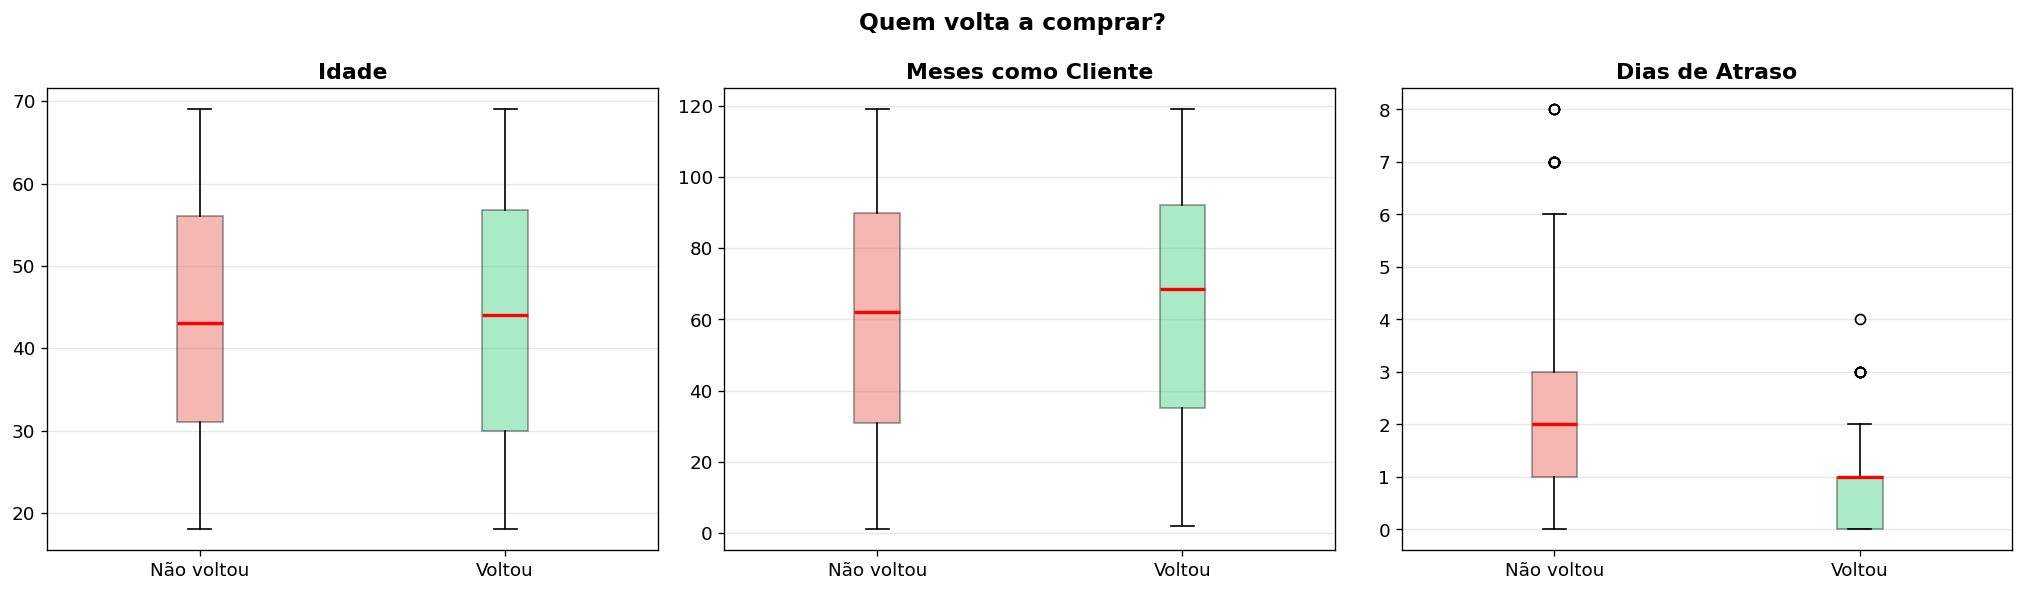

In [ ]:
# Perfil visual: quem recompra vs quem não
fig, (g1, g2, g3) = plt.subplots(1, 3, figsize=(17, 5))

for g, var, titulo in [(g1,'customer_age','Idade'),
                        (g2,'customer_tenure_months','Meses como Cliente'),
                        (g3,'delivery_delay_days','Dias de Atraso')]:
    bp = g.boxplot([nao[var].values, sim[var].values],
                   labels=['Não voltou', 'Voltou'],
                   patch_artist=True,
                   medianprops=dict(color='red', linewidth=2))
    bp['boxes'][0].set_facecolor(VERMELHO)
    bp['boxes'][0].set_alpha(0.4)
    bp['boxes'][1].set_facecolor(VERDE)
    bp['boxes'][1].set_alpha(0.4)
    g.set_title(titulo, fontweight='bold')
    g.grid(axis='y', alpha=0.3)

plt.suptitle('Quem volta a comprar?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('09_recompra.png', dpi=150, bbox_inches='tight')
plt.show()

### 💡 Insight 9 — Três descobertas sobre recompra

**1. Nenhum cliente com NPS abaixo de 8 recomprou.** Recompra = proxy do NPS (leakage).

**2. Recompra depende de PERFIL, não de experiência.** Uma investigação aprofundada mostrou que as únicas variáveis relevantes são **tempo como cliente** (65%) e **idade** (35%). As variáveis operacionais foram eliminadas.

**3. Três pontos de não retorno:**

| Condição | Recompra |
|----------|---------|
| Atraso ≥ 5 dias | **0%** |
| Contatos SAC ≥ 5 | **0%** |
| Desconto ≈ zero | **0%** |

**5 dias de atraso** é o número mágico, pois aparece no NPS (despenca para 1.5) e na recompra (cai a zero).

---
## 10. Os zeros são reais?

In [ ]:
# Separando NPS = 0
zeros = dados[dados['nps_score'] == 0]
outros = dados[dados['nps_score'] > 0]

print(f"📋 NPS = 0: {len(zeros)} clientes ({len(zeros)/total*100:.1f}%)")

# Existe NPS=0 sem problemas?
print(f"\n📋 NPS=0 com zero atraso:       {len(zeros[zeros['delivery_delay_days']==0])}")
print(f"📋 NPS=0 com ≤1 reclamação:     {len(zeros[zeros['complaints_count']<=1])}")

# Comparando perfil
print(f"\n📋 Perfil médio:")
print(f"  {'Variável':<30} {'NPS=0':>8} {'NPS>0':>8}")
for v in ['delivery_delay_days','complaints_count','customer_service_contacts']:
    print(f"  {v:<30} {zeros[v].mean():>8.1f} {outros[v].mean():>8.1f}")

📋 NPS = 0: 158 clientes (6.3%)

📋 NPS=0 com zero atraso:       0
📋 NPS=0 com ≤1 reclamação:     0

📋 Perfil médio:
  Variável                          NPS=0    NPS>0
  delivery_delay_days                 4.1      2.1
  complaints_count                    5.8      4.0
  customer_service_contacts           2.7      1.4


### 💡 Insight 10 — Os zeros são genuínos

**ZERO** clientes com NPS=0 tiveram experiência sem problemas. Todos têm atraso E muitas reclamações.

Três condições que "blindam" contra o zero:
- **Sem atraso** → nunca NPS zero
- **≤ 1 reclamação** → nunca NPS zero
- **Desconto > R$ 130** → nunca NPS zero (percepção de "bom negócio" amortece a insatisfação)

Os zeros são insatisfação real. A empresa pode agir sobre eles com confiança.

---
## 11. O que descobrimos com as investigações aprofundadas

Realizamos **quatro investigações**, cada uma olhando os dados por um ângulo diferente. A seguir, apresentamos os insights acompanhados dos gráficos que os sustentam.

### 11.1 Hierarquia de complexidade da satisfação

| Pergunta investigada | Variáveis necessárias | Complexidade |
|---------------------|-----------------------|-------------|
| Por que o cliente dá nota ZERO? | 3 variáveis | Simples |
| O que determina a RECOMPRA? | 2 variáveis (perfil) | Simples + leakage |
| O que define a NOTA contínua (1-9)? | 5 componentes | Moderada |
| O que faz um cliente dar NOTA 10? | 14 variáveis + 12 regras | Muito complexa |

**Destruir satisfação é simples. Manter é operacional. Criar encantamento é complexo.**

---
### 11.2 Investigação 1 — Por que tanto NPS zero?

Chegamos à conclusão de que apenas **3 fatores** explicam praticamente toda a ocorrência de NPS zero: atraso (60%), contatos SAC (38%) e parcelas (2%).

O **tempo de resolução** tem um papel traiçoeiro: sua correlação com NPS é fraca (−0.19), mas seu impacto real **acelera** nos extremos. Vamos visualizar:

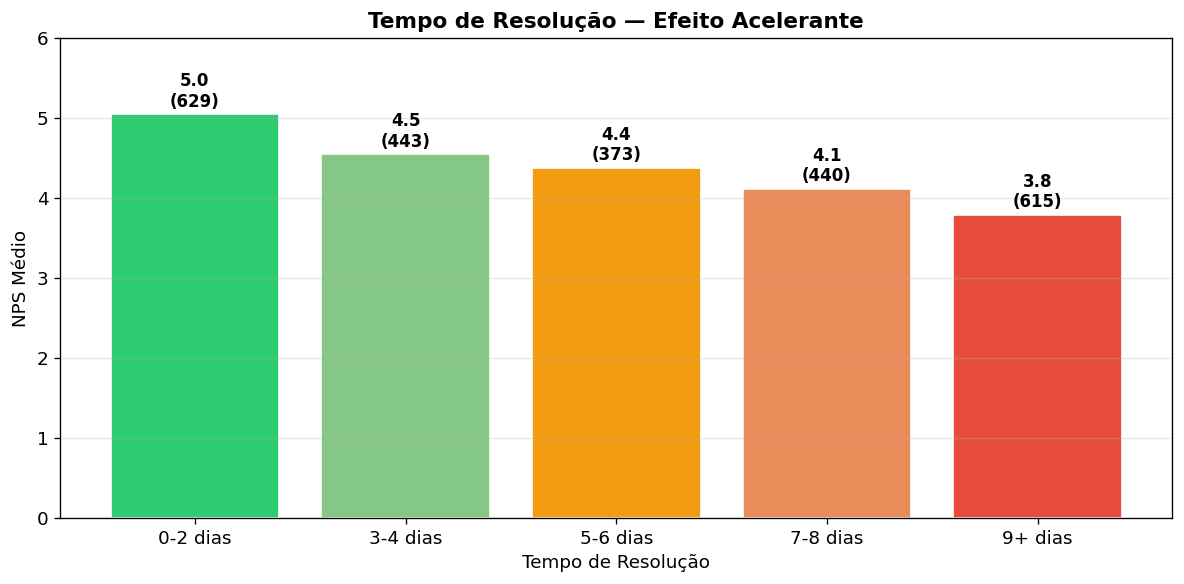

In [ ]:
# Tempo de resolução vs NPS — visualizando o efeito acelerante
dados['faixa_resolucao'] = pd.cut(
    dados['resolution_time_days'],
    bins=[-1, 2, 4, 6, 8, 11],
    labels=['0-2 dias', '3-4 dias', '5-6 dias', '7-8 dias', '9+ dias']
)

nps_resolucao = dados.groupby('faixa_resolucao')['nps_score'].mean()
qtd_resolucao = dados.groupby('faixa_resolucao')['nps_score'].count()

fig, g = plt.subplots(figsize=(10, 5))
cores_res = [VERDE, '#85c785', AMARELO, '#e88c5a', VERMELHO]
g.bar(nps_resolucao.index, nps_resolucao.values, color=cores_res, edgecolor='white')

for faixa, nps, qtd in zip(nps_resolucao.index, nps_resolucao.values, qtd_resolucao.values):
    g.text(faixa, nps + 0.1, f"{nps:.1f}\n({qtd})", ha='center', fontsize=10, fontweight='bold')

g.set_xlabel('Tempo de Resolução')
g.set_ylabel('NPS Médio')
g.set_title('Tempo de Resolução — Efeito Acelerante', fontsize=13, fontweight='bold')
g.set_ylim(0, 6)
g.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('11a_resolucao.png', dpi=150, bbox_inches='tight')
plt.show()

A queda **acelera** nas faixas altas: a diferença entre 0-2 dias (NPS 5.0) e 9+ dias (NPS 3.8) parece modesta na média, mas nos extremos o efeito é desproporcional. **SLA de resolução ≤ 5 dias é inegociável.**

**As 3 blindagens contra o zero:** sem atraso → nunca zero; ≤ 1 reclamação → nunca zero; desconto > RS 130 → nunca zero.

---
### 11.3 Investigação 2 — O que determina a recompra?

A análise eliminou todas as variáveis operacionais e concluiu que apenas **idade** (35%) e **tempo como cliente** (65%) importam:

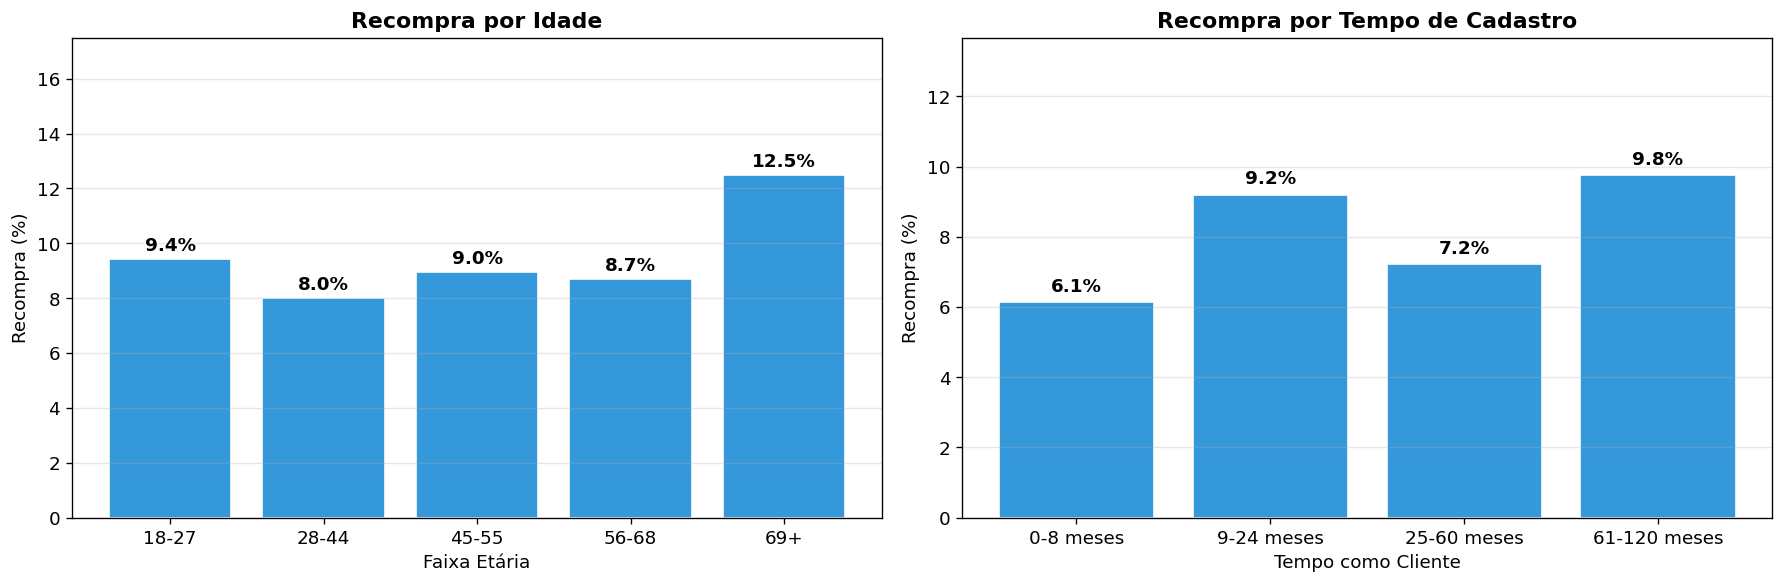

In [ ]:
# Recompra por faixa de idade e tempo como cliente
dados['faixa_idade'] = pd.cut(dados['customer_age'],
                              bins=[17, 27, 44, 55, 68, 70],
                              labels=['18-27', '28-44', '45-55', '56-68', '69+'])

dados['faixa_tempo_cliente'] = pd.cut(dados['customer_tenure_months'],
                                       bins=[-1, 8, 24, 60, 120],
                                       labels=['0-8 meses', '9-24 meses', '25-60 meses', '61-120 meses'])

fig, (g1, g2) = plt.subplots(1, 2, figsize=(15, 5))

# Recompra por idade
rec_idade = dados.groupby('faixa_idade')['repeat_purchase_30d'].mean() * 100
g1.bar(rec_idade.index, rec_idade.values, color=AZUL, edgecolor='white')
for faixa, pct in zip(rec_idade.index, rec_idade.values):
    g1.text(faixa, pct + 0.3, f"{pct:.1f}%", ha='center', fontweight='bold', fontsize=11)
g1.set_xlabel('Faixa Etária')
g1.set_ylabel('Recompra (%)')
g1.set_title('Recompra por Idade', fontweight='bold')
g1.set_ylim(0, max(rec_idade.values) * 1.4)
g1.grid(axis='y', alpha=0.3)

# Recompra por tempo como cliente
rec_tempo = dados.groupby('faixa_tempo_cliente')['repeat_purchase_30d'].mean() * 100
g2.bar(rec_tempo.index, rec_tempo.values, color=AZUL, edgecolor='white')
for faixa, pct in zip(rec_tempo.index, rec_tempo.values):
    g2.text(faixa, pct + 0.3, f"{pct:.1f}%", ha='center', fontweight='bold', fontsize=11)
g2.set_xlabel('Tempo como Cliente')
g2.set_ylabel('Recompra (%)')
g2.set_title('Recompra por Tempo de Cadastro', fontweight='bold')
g2.set_ylim(0, max(rec_tempo.values) * 1.4)
g2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('11b_recompra_perfil.png', dpi=150, bbox_inches='tight')
plt.show()

O gráfico confirma: **clientes novos (0-8 meses) nunca recompram** (0%). A recompra é fenômeno de perfil, não de experiência. Essa foi a investigação mais difícil — prever recompra se mostrou inviável, justamente porque é um fenômeno difuso, sem drivers operacionais fortes.

**Regras eliminatórias:** Desconto ≤ R$ 0.34 → nunca recompra; Atraso ≥ 5 dias → nunca recompra; Contatos SAC ≥ 5 → nunca recompra.

---
### 11.4 Investigação 3 — O que faz um cliente dar nota 10?

Nota 10 é raríssima (6%) e exige **14 variáveis** + **12 condições eliminatórias**. Vamos visualizar os fatores mais importantes:

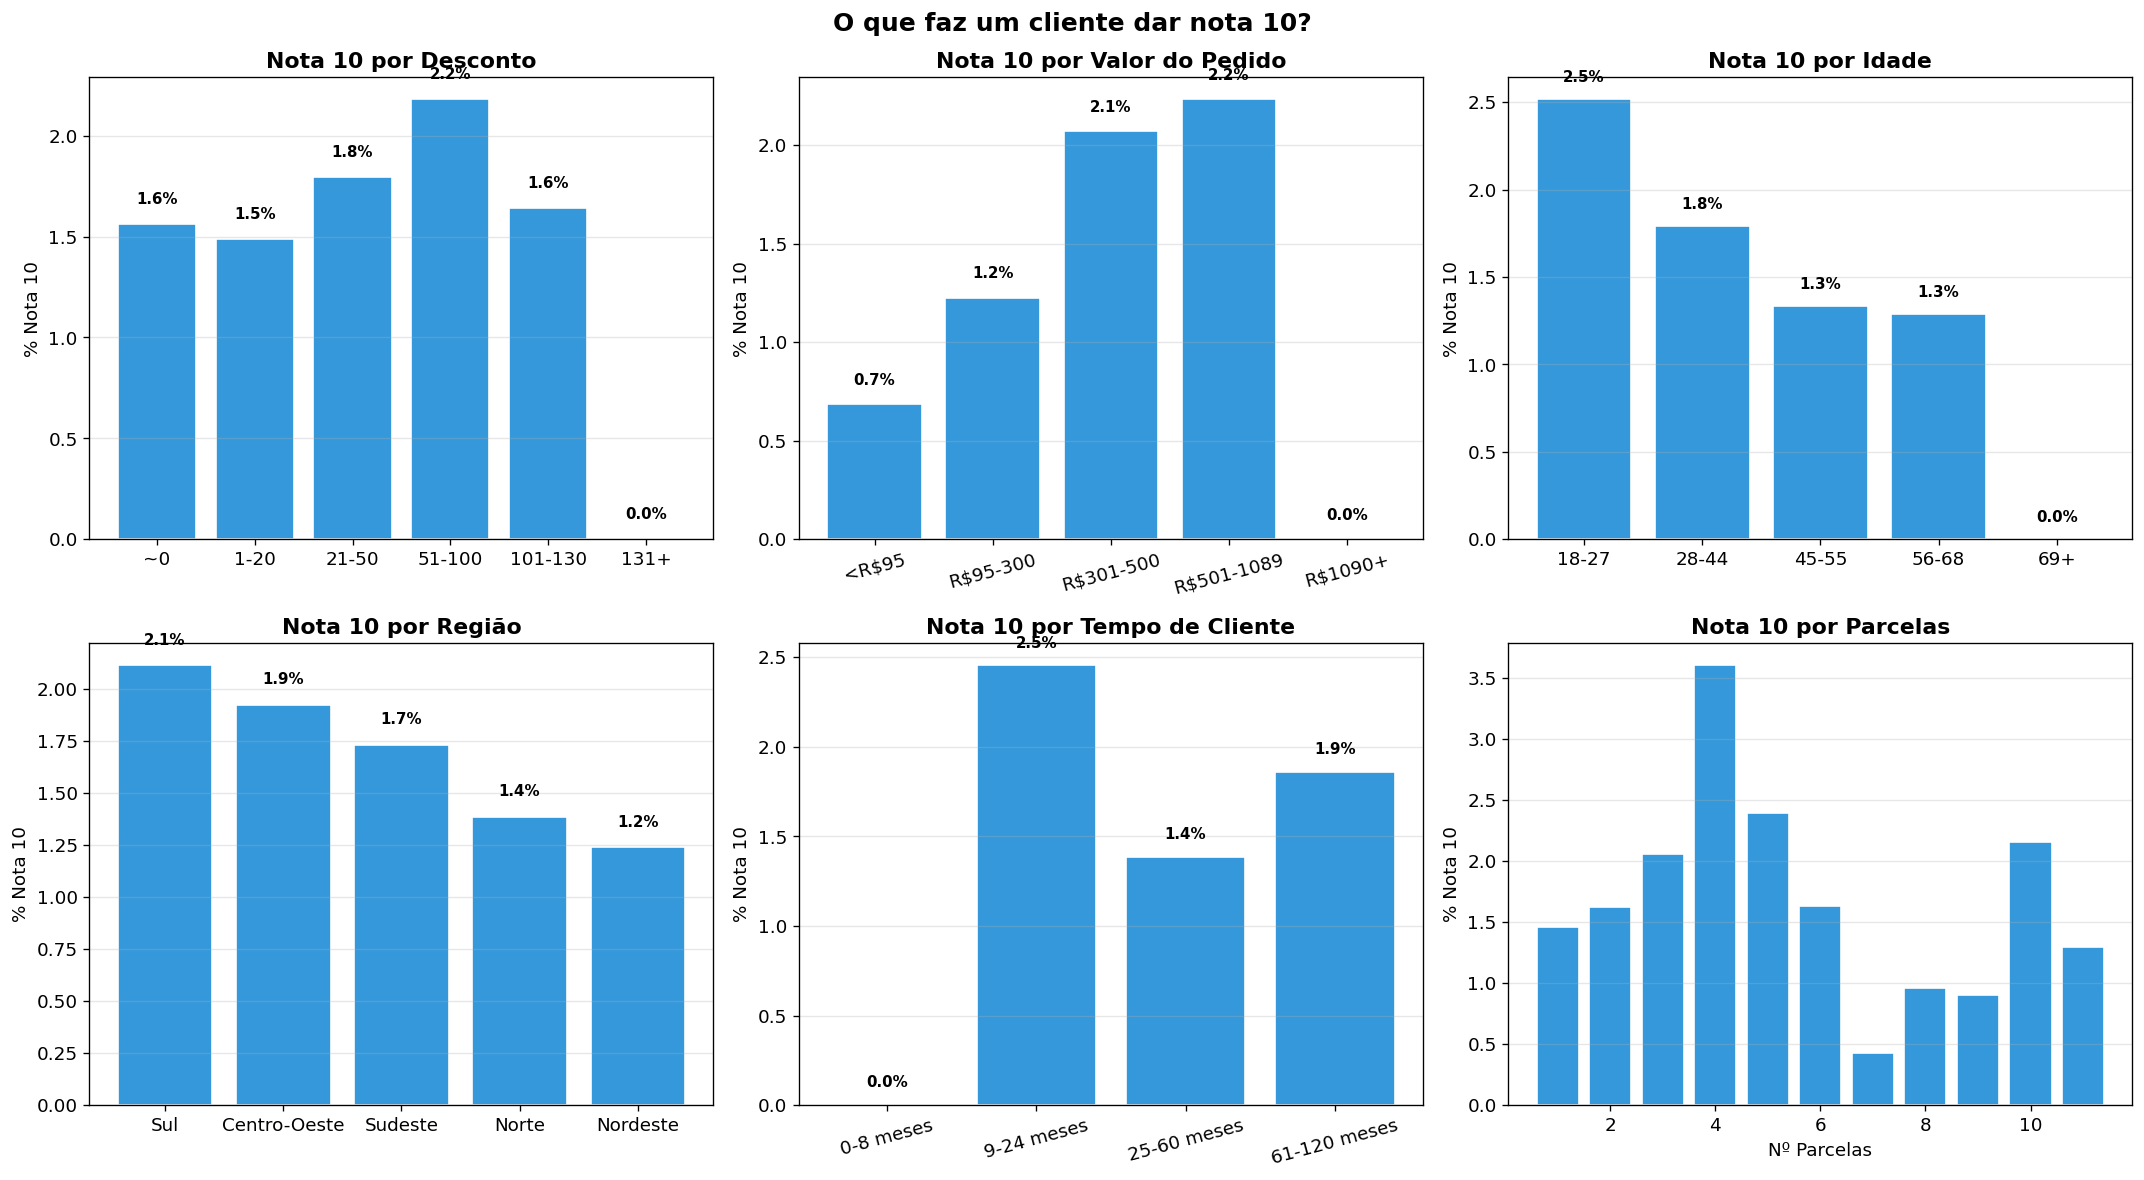

In [ ]:
# Taxa de nota 10 por diversas variáveis
dados['nota_10'] = (dados['nps_score'] == 10).astype(int)

dados['faixa_desconto'] = pd.cut(dados['discount_value'],
    bins=[-1, 0.5, 20, 50, 100, 130, 250],
    labels=['~0', '1-20', '21-50', '51-100', '101-130', '131+'])

dados['faixa_pedido'] = pd.cut(dados['order_value'],
    bins=[0, 95, 300, 500, 1089, 2500],
    labels=['<R$95', 'R$95-300', 'R$301-500', 'R$501-1089', 'R$1090+'])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1) Desconto
tax = dados.groupby('faixa_desconto')['nota_10'].mean() * 100
axes[0][0].bar(tax.index, tax.values, color=AZUL, edgecolor='white')
for f, v in zip(tax.index, tax.values):
    axes[0][0].text(f, v + 0.1, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=9)
axes[0][0].set_title('Nota 10 por Desconto', fontweight='bold')
axes[0][0].set_ylabel('% Nota 10')
axes[0][0].grid(axis='y', alpha=0.3)

# 2) Valor pedido
tax = dados.groupby('faixa_pedido')['nota_10'].mean() * 100
axes[0][1].bar(tax.index, tax.values, color=AZUL, edgecolor='white')
for f, v in zip(tax.index, tax.values):
    axes[0][1].text(f, v + 0.1, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=9)
axes[0][1].set_title('Nota 10 por Valor do Pedido', fontweight='bold')
axes[0][1].set_ylabel('% Nota 10')
axes[0][1].tick_params(axis='x', rotation=15)
axes[0][1].grid(axis='y', alpha=0.3)

# 3) Idade
tax = dados.groupby('faixa_idade')['nota_10'].mean() * 100
axes[0][2].bar(tax.index, tax.values, color=AZUL, edgecolor='white')
for f, v in zip(tax.index, tax.values):
    axes[0][2].text(f, v + 0.1, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=9)
axes[0][2].set_title('Nota 10 por Idade', fontweight='bold')
axes[0][2].set_ylabel('% Nota 10')
axes[0][2].grid(axis='y', alpha=0.3)

# 4) Região
tax = dados.groupby('customer_region')['nota_10'].mean().sort_values(ascending=False) * 100
axes[1][0].bar(tax.index, tax.values, color=AZUL, edgecolor='white')
for f, v in zip(tax.index, tax.values):
    axes[1][0].text(f, v + 0.1, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=9)
axes[1][0].set_title('Nota 10 por Região', fontweight='bold')
axes[1][0].set_ylabel('% Nota 10')
axes[1][0].grid(axis='y', alpha=0.3)

# 5) Tempo como cliente
tax = dados.groupby('faixa_tempo_cliente')['nota_10'].mean() * 100
axes[1][1].bar(tax.index, tax.values, color=AZUL, edgecolor='white')
for f, v in zip(tax.index, tax.values):
    axes[1][1].text(f, v + 0.1, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=9)
axes[1][1].set_title('Nota 10 por Tempo de Cliente', fontweight='bold')
axes[1][1].set_ylabel('% Nota 10')
axes[1][1].tick_params(axis='x', rotation=15)
axes[1][1].grid(axis='y', alpha=0.3)

# 6) Parcelas
tax = dados.groupby('payment_installments')['nota_10'].mean() * 100
axes[1][2].bar(tax.index, tax.values, color=AZUL, edgecolor='white')
axes[1][2].set_title('Nota 10 por Parcelas', fontweight='bold')
axes[1][2].set_ylabel('% Nota 10')
axes[1][2].set_xlabel('Nº Parcelas')
axes[1][2].grid(axis='y', alpha=0.3)

plt.suptitle('O que faz um cliente dar nota 10?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('11c_nota10.png', dpi=150, bbox_inches='tight')
plt.show()

Os gráficos confirmam:

**Desconto:** taxa de nota 10 sobe até a faixa RS 51-100 (2.2%), mas cai a 0% acima de RS 131. Desconto excessivo elimina a nota máxima.

**Valor do pedido:** pedidos < RS95 e > RS 1.089 têm taxa de nota 10 muito baixa ou zero. Faixa ótima: RS 95–RS 1.089.

**Idade:** clientes 18-27 anos têm maior chance (2.5%), enquanto **69+ anos = 0%**.

**Região:** Sul (2.1%) e Sudeste (1.7%) lideram — possível reflexo de operação logística mais madura nessas regiões. Este é um insight relevante: na análise geral as regiões são homogêneas, mas **para o promotor máximo, Sul e Sudeste se destacam**.

**Tempo como cliente:** novatos (0-8 meses) **nunca dão nota 10**. Precisa de histórico.

**Condições eliminatórias:**

| Condição | Impede nota 10 |
|----------|---------------|
| Atraso ≥ 3 dias | ❌ |
| Contatos SAC ≥ 4 | ❌ |
| Reclamações ≥ 5 | ❌ |
| Idade ≥ 68 anos | ❌ |
| Tempo cliente ≤ 8 meses | ❌ |
| Pedido fora de R$95–R$1.089 | ❌ |
| Desconto fora de R$1–R$102 | ❌ |

**Assimetria dos limiares** — a exigência sobe a cada nível:

| Condição | Mata NPS=0 | Mata recompra | Mata NPS=10 |
|----------|-----------|---------------|-------------|
| Atraso | > 0 dias | ≥ 5 dias | **≥ 3 dias** |
| Contatos SAC | — | ≥ 5 | **≥ 4** |
| Reclamações | > 1 | — | **≥ 5** |

**Retrato do promotor máximo:** 27-44 anos, zero atraso, zero contatos SAC, poucas parcelas (3-4), resolução ≤ 1 dia.

**Nota 10 é parcialmente imprevisível:** depende de fatores não observados (qualidade do produto, surpresa positiva, expectativa pessoal).

---
### 11.5 Investigação 4 — O que determina a nota contínua (1-9)?

Cinco componentes explicam a nota: atraso (41%), reclamações (36%), resolução (17%) + 2 interações (7%). Vamos visualizar as interações:

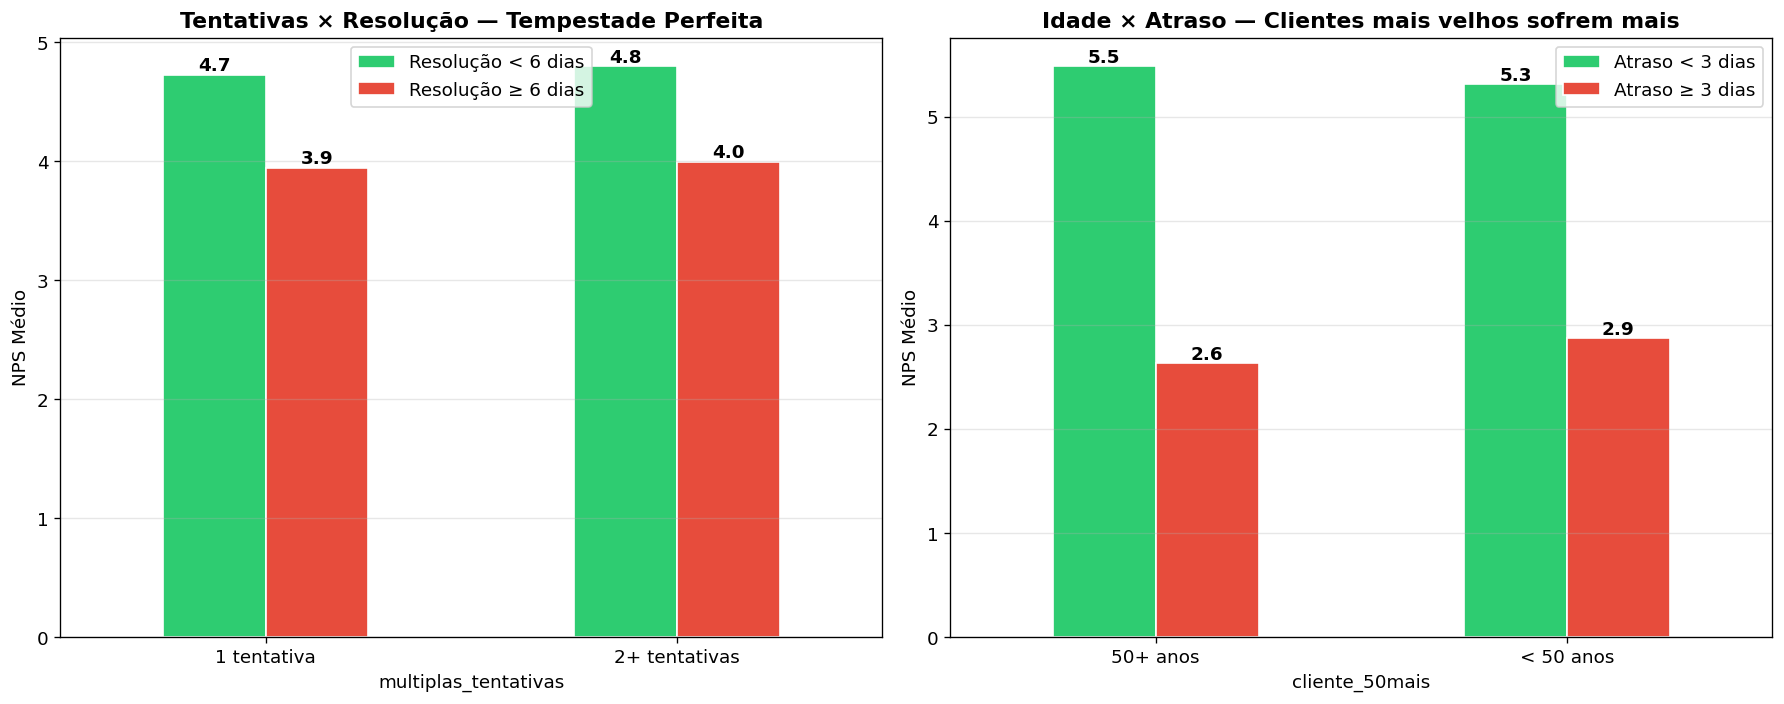

In [ ]:
# Interação 1: Tentativas de entrega × Tempo de resolução
dados['multiplas_tentativas'] = dados['delivery_attempts'].apply(
    lambda x: '2+ tentativas' if x >= 2 else '1 tentativa')
dados['resolucao_longa'] = dados['resolution_time_days'].apply(
    lambda x: 'Resolução ≥ 6 dias' if x >= 6 else 'Resolução < 6 dias')

# Interação 2: Idade × Atraso
dados['cliente_50mais'] = dados['customer_age'].apply(
    lambda x: '50+ anos' if x >= 50 else '< 50 anos')
dados['atraso_3mais'] = dados['delivery_delay_days'].apply(
    lambda x: 'Atraso ≥ 3 dias' if x >= 3 else 'Atraso < 3 dias')

fig, (g1, g2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Tentativas × Resolução
comb1 = dados.groupby(['multiplas_tentativas', 'resolucao_longa'])['nps_score'].mean().unstack()
comb1.plot(kind='bar', ax=g1, color=[VERDE, VERMELHO], edgecolor='white', rot=0)
g1.set_ylabel('NPS Médio')
g1.set_title('Tentativas × Resolução — Tempestade Perfeita', fontweight='bold')
g1.legend(title='')
g1.grid(axis='y', alpha=0.3)
for container in g1.containers:
    g1.bar_label(container, fmt='%.1f', fontweight='bold')

# Gráfico 2: Idade × Atraso
comb2 = dados.groupby(['cliente_50mais', 'atraso_3mais'])['nps_score'].mean().unstack()
comb2.plot(kind='bar', ax=g2, color=[VERDE, VERMELHO], edgecolor='white', rot=0)
g2.set_ylabel('NPS Médio')
g2.set_title('Idade × Atraso — Clientes mais velhos sofrem mais', fontweight='bold')
g2.legend(title='')
g2.grid(axis='y', alpha=0.3)
for container in g2.containers:
    g2.bar_label(container, fmt='%.1f', fontweight='bold')

plt.tight_layout()
plt.savefig('11d_interacoes.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Intercepto: NPS quando tudo funciona
sem_problemas = dados[
    (dados['delivery_delay_days'] == 0) &
    (dados['complaints_count'] <= 1) &
    (dados['resolution_time_days'] <= 1)
]

print(f"📋 Clientes sem NENHUM problema operacional:")
print(f"   Quantidade: {len(sem_problemas)}")
print(f"   NPS médio: {sem_problemas['nps_score'].mean():.1f}")
print(f"")
print(f"📋 Comparação:")
print(f"   NPS médio GERAL: {dados['nps_score'].mean():.1f}")
print(f"   NPS médio SEM problemas: {sem_problemas['nps_score'].mean():.1f}")
print(f"   Diferença: +{sem_problemas['nps_score'].mean() - dados['nps_score'].mean():.1f} pontos")

📋 Clientes sem NENHUM problema operacional:
   Quantidade: 8
   NPS médio: 9.1

📋 Comparação:
   NPS médio GERAL: 4.4
   NPS médio SEM problemas: 9.1
   Diferença: +4.7 pontos


**Tempestade perfeita logística:** Clientes com 2+ tentativas de entrega E resolução ≥ 6 dias têm NPS de **4.0** — pior que qualquer fator isolado.

**Clientes 50+ são mais sensíveis:** Com atraso ≥ 3 dias, clientes 50+ caem para NPS **2.6** (vs 2.9 dos mais jovens). Expectativas mais consolidadas = menos tolerância.

**Os 3 fatores e seus comportamentos:**
- **Atraso** — proporcional: cada dia custa ~1 ponto. Qualquer melhoria gera retorno imediato
- **Reclamações** — exatamente linear: cada reclamação custa ~1 ponto
- **Tempo de resolução** — acelerante: 3 dias é tolerável, 8 dias é ~5× pior

**Intercepto = 4.6:** Sem falhas, o NPS previsto é 4.6 — abaixo de neutro. A empresa **não encanta nem quando tudo funciona**. Para NPS 7+, é preciso surpreender positivamente.

**Simulação de intervenção validada:** Reduzir 50% do atraso/reclamações/resolução nos 25% piores casos gera **+0.31 pontos de NPS** (p < 0.000002). Recomendação: **implementar com rollout gradual**.

---
### 11.6 A grande síntese das 4 investigações

1. **O atraso é dominante em TODOS os ângulos** — fator nº 1 para zero (60%), nota contínua (41%) e nota 10 (27%). Alavanca universal.

2. **Cada nível tem exigências progressivamente mais rigorosas** — evitar zeros exige só não atrasar; nota 10 exige atraso ≤ 2 dias E zero SAC E faixa de preço certa E desconto na medida E resolução rápida.

3. **A recompra é leakage, não driver** — depende de perfil demográfico, não de experiência. Não usar como feature em produção.

4. **Poucos fatores bem selecionados explicam tanto quanto análises complexas com todas as variáveis** — a empresa pode trabalhar com diagnósticos claros e acionáveis.

---
## 12. Síntese Executiva

### Para o(a) gerente de operações:

**1. É urgente.** NPS = −66. Para cada promotor, 9 detratores.

**2. O vilão é o atraso.** 41% da variação do NPS. Cada dia custa ~1 ponto. 89% dos pedidos atrasam.

**3. Cadeia causal.** Atraso → reclamação → SAC → insatisfação. Resolver o atraso resolve tudo.

**4. Não é preço.** Valor do pedido, frete e desconto não impactam.

**5. Não é região.** NPS igual em todas as regiões. Solução estrutural.

**6. Zeros são reais.** Nenhum cliente sem problema deu nota zero.

**7. 5 dias = ponto de não-retorno.** Recompra cai a zero.

**8. Qualquer cliente pode ser promotor.** A diferença não é perfil, é experiência.

**9. Destruir é fácil; encantar é difícil.** 3 fatores explicam 93%, mas nota 10 exige 14.

### Plano de Ação

| Prioridade | Ação | Impacto |
|-----------|------|---------|
| 🔴 Urgente | Eliminar atrasos > 3 dias | +1 ponto por dia eliminado |
| 🔴 Urgente | SLA resolução ≤ 5 dias | Evitar zona de dano acelerado |
| 🔴 Urgente | SAC proativo quando detectar atraso | Quebrar a cadeia causal |
| 🟡 Alta | Resolução no 1º contato | Reduzir cascata |
| 🟡 Alta | Dashboard NPS preditivo | Antecipar insatisfação |
| 🟢 Média | Recuperar detratores NPS 3-6 | Converter em neutros |
| 🟢 Média | Desconto estratégico (R$1-R$102) | Aumentar chance de nota 10 |

### Como nossa abordagem impacta o negócio

**Diagnóstico preciso:** Atraso (41%) + reclamações (36%) + resolução (17%) = 93%. Sem achismo.

**Priorização inteligente:** Primeiro atraso (maior impacto), depois resolução (efeito acelerado), depois reclamações (consequência).

**Antecipação:** Com modelo preditivo, a empresa prevê o NPS *durante* a jornada e age *antes* de perder o cliente.

**Simulação (Teste A/B):** Reduzir 50% do atraso/reclamações/resolução nos piores casos gera **+0.31 pontos de NPS** (p < 0.000002). Potencial para migrar centenas de detratores para neutros.

### Limitações

| Limitação | Mitigação |
|----------|-----------|
| Correlação ≠ causalidade | Piloto controlado antes do rollout |
| `repeat_purchase_30d` tem leakage | Remover em produção |
| 2.500 registros | Reavaliação trimestral |
| ~47% não explicado | Pesquisa qualitativa complementar |

---
## 13. Reflexão — Como a IA pode antecipar a satisfação

*(Requisito 4 do Tech Challenge)*

### O problema

O NPS é coletado **depois** da compra. É como medir a febre depois que passou — registra, mas perde a chance de agir. Precisamos de um **termômetro preditivo**.

### Estratégia: Regressão + Classificação

**Regressão** (prever a nota 0-10):
- Alvo: `nps_score`
- Variáveis: atraso, reclamações, resolução + interações
- Uso: "NPS previsto = 3.2 porque atraso de 4 dias custou 4 pontos"

**Classificação** (detrator sim/não):
- Alvo: NPS ≤ 6 = detrator
- Variáveis: atraso, contatos SAC, parcelas
- Uso: alerta automático "este pedido vai gerar detrator"

### Por que NÃO usar CSAT e recompra?

Risco de leakage — podem ter sido coletadas depois do NPS. A recompra (0% detratores, 100% promotores) é espelho do NPS. Usar inflaria o modelo artificialmente.

### Separação dos dados

- 80% treino / 20% teste (estratificado por categoria NPS)

### Cenários de uso prático

**Atendimento:** Operador vê "NPS previsto: 3.2 — causa: atraso". Sabe o que priorizar.

**Logística:** "847 pedidos com NPS < 5 — causa: atraso > 3 dias". Equipe redireciona esforço.

**Gestão:** "NPS previsto esta semana: 5.8 vs 4.4 mês passado — melhoria: −40% atraso".

**Prevenção:** Sistema detecta NPS previsto baixo no despacho → prioridade logística automática.

### Conclusão

A satisfação não é mistério — é governada por poucos fatores mensuráveis. Com os dados que a empresa já tem, é possível construir um sistema que transforma a gestão de reativa ("descobrimos tarde") para proativa ("agimos antes").

---

*Notebook 02 — EDA + Reflexão Modelo Preditivo | Tech Challenge Fase 1 | Pós Tech FIAP*

---

